# TRUST Additional Validation Data

## First combine data from genotypic samples and patients

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob, os, yaml, sparse, itertools, subprocess, sys, pickle, re, collections, shutil
from functools import reduce

import Bio.SeqUtils
import Bio.Data
from Bio import SeqIO
from Bio.Seq import Seq

plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlepad'] = 10
import scipy.stats as st
import warnings
warnings.filterwarnings("ignore")

# load all utils functions
# sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "utils"))
# from data_utils import *
# from inSilicoMut_utils import *

os.chdir("../")
sys.path.append("utils")
from data_utils import *
from inSilicoMut_utils import *

from matplotlib.ticker import FormatStrFormatter
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"
data_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"
model_loci = pd.read_csv("./data_processing/data_utils/drug_loci.csv")

# # who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")
# who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_resistance_variants_all.csv")
# who_variants_clean = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")

h37Rv = SeqIO.read("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")
h37Rv_genes = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/mycobrowser_h37rv_genes_v4.csv")

# coll2014 = pd.read_csv("/home/sak0914/who-analysis/data/coll2014_SNP_scheme.tsv", sep="\t")
# coll2014["#lineage"] = coll2014["#lineage"].str.replace("lineage", "")
# coll2014.rename(columns={"#lineage": "Lineage"}, inplace=True)

# solo_results = pd.read_excel("/home/sak0914/who-analysis/data/SOLO primary_STATA_ver18Feb2023.xlsx", sheet_name=None)

# if len(solo_results) == 1:
#     solo_results = solo_results[list(solo_results.keys())[0]]

drug_abbr_dict = {"Delamanid": "DLM",
                  "Bedaquiline": "BDQ",
                  "Clofazimine": "CFZ",
                  "Ethionamide": "ETA",
                  "Linezolid": "LZD",
                  "Moxifloxacin": "MXF",
                  "Capreomycin": "CAP",
                  "Amikacin": "AMI",
                  "Pretomanid": "PTM",
                  "Pyrazinamide": "PZA",
                  "Kanamycin": "KAN",
                  "Levofloxacin": "LEV",
                  "Streptomycin": "STM",
                  "Ethambutol": "EMB",
                  "Isoniazid": "INH",
                  "Rifampicin": "RIF"
                 }

isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/WHO_catalog_isolate_variants.csv")

who_variants = pd.read_csv("./data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
silent_lst = ['synonymous_variant', 'initiator_codon_variant', 'stop_retained_variant']

cc_df = pd.read_csv("/home/sak0914/who-analysis/data/drug_CC.csv")

In [2]:
######## CODE TO ADD ADDITIONAL SAMPLES TO THE LINEAGE MATRIX FOR PREDICTION ########

# df_genos = pd.read_csv("../MtbQuantCNN/data_processing/samples_pass_geno_QC.csv")

# dir_names = ['/n/data1/hms/dbmi/farhat/rollingDB/TRUST/231218.TRUST.Illumina.Batch3.Output', '/n/data1/hms/dbmi/farhat/rollingDB/TRUST/240528.TRUST.Illumina.Batch4.Output']
# flc_results = []

# for sample in missing_samples:
    
#     for dir_name in dir_names:
#         if os.path.isdir(f"{dir_name}/{sample}"):
#             select_dir_name = f"{dir_name}/{sample}"
#             break

#     flc_fName = f"{dir_name}/{sample}/lineage_calling/{sample}_lineage.tsv"
#     assert os.path.isfile(flc_fName)

#     vcf_fName = f"{dir_name}/{sample}/pilon/{sample}_variants.vcf"
#     assert os.path.isfile(vcf_fName)

#     F2_fName = f"{dir_name}/{sample}/lineage_calling/{sample}_F2_Coll2014.txt"
#     assert os.path.isfile(F2_fName)
#     F2_val = pd.read_csv(F2_fName, sep='\t', header=None)[0].values[0]

#     df = pd.read_csv(flc_fName, sep='\t')
    
#     for col in df.columns:
#         df.rename(columns={col: col.capitalize()}, inplace=True)

#     df.loc[0, ['ROLLINGDB_ID', 'DB_OF_ORIGIN', 'F2', 'VCF']] = [df['Isolate'].values[0].replace('_variants', ''), 'TRUST', F2_val, vcf_fName]
#     del df['Isolate']
    
#     flc_results.append(df)

# flc_results = pd.concat(flc_results).reset_index(drop=True)
# flc_results['Coll2014'] = flc_results['Coll2014'].str.replace('lineage', '')
# flc_results['Lineage'] = flc_results['Coll2014'].str[0]

# pd.concat([df_genos, flc_results])

In [3]:
def combine_TRUST_patient_samples(df_trust_patients, samples_report):

    print(f"{len(df_trust_patients.patient_num.unique())} patients in phenotypes dataframe")
    
    # each sample ID is in the format like 260-04, S0299-01, or S0271-01A. So use re to remove all alpha characters and keep only numbers.
    # first number is the patient number, second is the sample number
    # merge the patient number extracted from each sample with the patient numbers in df_trust_patients
    samples_report["patient_num"] = [int(re.findall(r'\d+', val.split("-")[0])[0]) for val in samples_report["Original_ID"].values]
    samples_report["sample_week"] = [int(re.findall(r'\d+', val.split("-")[1])[0]) for val in samples_report["Original_ID"].values]

    # keep only samples for the patients in df_trust_patients
    #df_trust_report = df_trust_report.query("patient_num in @df_trust_patients.patient_num.unique()")
    samples_report = samples_report.merge(df_trust_patients[["pid", "patient_num"]], on="patient_num", how="inner")
    print(f"Found {len(samples_report.patient_num.unique())}/{len(df_trust_patients.patient_num.unique())} patients")
    
    # rename some columns that have spaces in them
    samples_report = samples_report.rename(columns={"Cov Any Mean": "Cov_Any_Mean",
                                        "Cov Unam Perc": "Cov_Unam_Perc",
                                        "Perc. Reads Mapped": "Perc_Reads_Mapped",
                                        "phylogenetic classification (Coll et al., 2014)": "Coll2014_Annotated"
                                       })

    # samples_report["Coll2014"] = [val.split(" ")[0] for val in samples_report["Coll2014_Annotated"].values]
    # samples_report["Lineage"] = [val.split(".")[0] for val in samples_report["Coll2014"].values]

    # get VCF file paths
    samples_report = samples_report.reset_index(drop=True)
    
    for i, row in samples_report.iterrows():

        sample_id = row["SampleID"]
        fName = f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/VCF/{sample_id}.vcf"

        if os.path.isfile(fName):
            samples_report.loc[i, "VCF"] = fName
        # failed kraken classification: meaning fewer than 90% of reads aligned to MTBC database
        # else:
        # # if not found_vcf_file:
        #     print(f"VCF file for {sample_id} not found!")

    # also remove contaminated samples
    return samples_report

In [4]:
df_trust_patients = pd.read_csv("./analysis/TRUST_MIC_20240826_with_method_updates.csv")
df_trust_patients["patient_num"] = [int(patient_id.replace("T0", "")) for patient_id in df_trust_patients["pid"].values]

# # from Brendon email September 5, 2024
# df_trust_patients.loc[(pd.isnull(df_trust_patients['s_inhmicmeth_sputum_specimen_1'])) & (~pd.isnull(df_trust_patients['s_inhmic_sputum_specimen_1'])), 's_inhmicmeth_sputum_specimen_1'] = 3
# df_trust_patients.loc[df_trust_patients['pid']=='T0097', 's_inhmicmeth_sputum_specimen_2'] = 2
# df_trust_patients.loc[df_trust_patients['pid']=='T0063', 's_inhmicmeth_sputum_specimen_2'] = 3
# df_trust_patients.to_csv("./analysis/TRUST_MIC_20240826_with_method_updates.csv", index=False)

trust_report_fNames = glob.glob("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/*.xlsx")

df_trust_report = []

# sort chronologically because below, we preferentially keep the later one
for fName in np.sort(trust_report_fNames)[::-1]:
    df = pd.read_excel(fName, sheet_name=None)

    df = df['summary'].rename(columns={'original ID': 'Original_ID'})
    df_trust_report.append(df)

df_trust_report = pd.concat(df_trust_report).dropna(subset='SampleID').drop_duplicates('SampleID', keep='last').reset_index(drop=True).query("status!='failed'") 
df_trust_report = df_trust_report.loc[~((~pd.isnull(df_trust_report['comment'])) & (df_trust_report['comment'].str.contains('contaminat')))].reset_index(drop=True)

# remove failed and Pacbio
df_trust_report = df_trust_report.query("Pacbio != 1 & status != 'failed'").reset_index(drop=True)

df_trust = combine_TRUST_patient_samples(df_trust_patients, df_trust_report)

# from Sarah Thompson email on 09/15/2023 bc they failed time to culture conversion analysis
exclude_lst = ['T0086', 'T0248', 'T0254', 'T0267', 'T0279']
df_trust = df_trust.query("pid not in @exclude_lst")

print(f"{df_trust.pid.nunique()} pids have WGS passing quality control")
print(f"{df_trust.SampleID.nunique()} WGS samples")

samples_with_FQ = glob.glob("/n/data1/hms/dbmi/farhat/fastq_db/TRUST_Illumina/TRUST.SRWGS.FQs.AllSets.RenamedAndLanesMerged/*/*")
samples_with_FQ = np.unique([os.path.basename(fName).split('_')[0] for fName in samples_with_FQ])
print(f"Have {len(samples_with_FQ)} FASTQs total")

df_genos = pd.read_csv("../MtbQuantCNN/data_processing/samples_pass_geno_QC.csv")
df_trust = df_trust.merge(df_genos[['ROLLINGDB_ID', 'F2', 'Coll2014']].rename(columns={'ROLLINGDB_ID': 'SampleID'}), how='left')

df_trust.to_csv("./analysis/TRUST_combined_samples_patients.csv", index=False)
df_trust = pd.read_csv("./analysis/TRUST_combined_samples_patients.csv")

# check that all samples with FASTQs have been processed to VCF stage
assert len(df_trust.loc[pd.isnull(df_trust['VCF'])].query("SampleID in @samples_with_FQ")) == 0

# add SampleID column
df_trust_patients = df_trust_patients.merge(df_trust)

452 patients in phenotypes dataframe
Found 360/452 patients
355 pids have WGS passing quality control
589 WGS samples
Have 635 FASTQs total


In [5]:
# don't have FASTQs for these yet
df_trust.loc[pd.isnull(df_trust['VCF'])].query("SampleID not in @samples_with_FQ").shape

(11, 24)

# Save MIC Only Dataframe to rollingDB

In [6]:
def get_all_available_MICs_single_drug(drug):

    # Function to extract the numeric part of the column name
    def extract_number(col_name):
        return int(col_name.split('_')[-1])
    
    df_MIC_single_drug = df_trust_patients[['Original_ID', 'pid', 'SampleID', 'VCF', 'F2', 'Coll2014'] +
                                            list(df_trust_patients.columns[df_trust_patients.columns.str.contains(f's_{drug.lower()}mic_sputum_specimen')])
    ]

    # get the MIC testing media too
    df_MIC_methods_single_drug = df_trust_patients[['Original_ID', 'pid', 'SampleID', 'VCF', 'F2', 'Coll2014'] +
                                                    list(df_trust_patients.columns[df_trust_patients.columns.str.contains(f's_{drug.lower()}micmeth')])
    ]
    
    df_MIC_single_drug = df_MIC_single_drug.set_index(['Original_ID', 'pid', 'SampleID', 'VCF', 'F2', 'Coll2014'])
    df_MIC_methods_single_drug = df_MIC_methods_single_drug.set_index(['Original_ID', 'pid', 'SampleID', 'VCF', 'F2', 'Coll2014'])
    
    # Reorder the columns based on the numeric part of their names
    df_MIC_single_drug = df_MIC_single_drug.reindex(sorted(df_MIC_single_drug.columns, key=extract_number), axis=1)
    df_MIC_methods_single_drug = df_MIC_methods_single_drug.reindex(sorted(df_MIC_methods_single_drug.columns, key=extract_number), axis=1)
    
    # get the first column
    df_MIC_single_drug[drug] = df_MIC_single_drug.iloc[:, 0].values

    # iterate through the remaining and fill NaNs
    for col in df_MIC_single_drug.columns[1:]:
        df_MIC_single_drug[drug] = df_MIC_single_drug[drug].fillna(df_MIC_single_drug[col])

    # keep only patient IDs with a measured MIC
    df_MIC_single_drug = df_MIC_single_drug.dropna(subset=drug).reset_index()
    
    # PZA MICs were all measured in MGIT, so there are no method columns
    if drug != 'PZA':

        # get the first column
        df_MIC_methods_single_drug[f"{drug}_method_num"] = df_MIC_methods_single_drug.iloc[:, 0].values
        
        for col in df_MIC_methods_single_drug.columns[1:]:
            df_MIC_methods_single_drug[f"{drug}_method_num"] = df_MIC_methods_single_drug[f"{drug}_method_num"].fillna(df_MIC_methods_single_drug[col])
            
        # keep only patient IDs with a measured MIC
        df_MIC_methods_single_drug = df_MIC_methods_single_drug.dropna(subset=f"{drug}_method_num").reset_index()
    
        # merge and add the testing method. Other = Agar proportion method. What media does it use?
        media_dict = {1: 'Microtiter_plate', 2: 'MGIT', 3: '7H10'}
        df_MIC_methods_single_drug[f"{drug}_method"] = df_MIC_methods_single_drug[f"{drug}_method_num"].map(media_dict)        

        # some method rows are NaN, so merge left
        # keep only pids that we have WGS for
        return df_MIC_single_drug.merge(df_MIC_methods_single_drug[["pid", f"{drug}_method_num", f"{drug}_method"]], how='left').drop_duplicates()

    else:
        df_MIC_single_drug[f"{drug}_method"] = 'MGIT'

        # keep only pids that we have WGS for
        return df_MIC_single_drug.drop_duplicates()

In [7]:
RIF_MIC_encoding_dict = {1: '0,0.03', 2: '0.03,0.06', 3: '0.06,0.125', 4: '0.125,0.25', 5: '0.25,0.5', 6: '0.5,1', 7: '1,10000'}
INH_MIC_encoding_dict = {1: '0,0.025', 2: '0.025,0.05', 3: '0.05,0.1', 4: '0.1,0.2', 5: '0.2,100000'}
EMB_MIC_encoding_dict = {1: '0,0.6', 2: '0.6,1.25', 3: '1.25,2.5', 4: '2.5,5', 5: '5,100000'}
PZA_MIC_encoding_dict = {1: '0,25', 2: '25,50', 3: '50,75', 4: '75,100', 5: '100,100000'}

RIF_label_encoding_dict = {1: '≤0.03', 2: '0.03-0.06', 3: '0.06-0.125', 4: '0.125-0.25', 5: '0.25-0.5', 6: '0.5-1', 7: '>1'}
INH_label_encoding_dict = {1: '≤0.025', 2: '0.025-0.05', 3: '0.05-0.1', 4: '0.1-0.2', 5: '>0.2'}
EMB_label_encoding_dict = {1: '≤0.6', 2: '0.6-1.25', 3: '1.25-2.5', 4: '2.5-5', 5: '>5'}
PZA_label_encoding_dict = {1: '0-25', 2: '25-50', 3: '50-75', 4: '75-100', 5: '>100'}

cc_dict = {'RIF': 0.5, 'INH': 0.2, 'EMB': 5, 'PZA': 100}

df_TRUST_rollingDB = []

for drug in ['RIF', 'INH', 'EMB', 'PZA']:
    
    # this contains all WGS runs, so keep only the unique pids for counting/plotting purposes
    df_single_drug = get_all_available_MICs_single_drug(drug)
    
    df_single_drug = df_single_drug[['pid', drug, f"{drug}_method"]].drop_duplicates()
    df_single_drug[f'{drug}_method'] = df_single_drug[f'{drug}_method'].replace('Other', '7H10')

    print(f"{len(df_single_drug)} patients have MICs for {drug}")
    df_TRUST_rollingDB.append(df_single_drug)

df_TRUST_rollingDB = reduce(lambda left, right: pd.merge(left, right, on='pid', how='outer'), df_TRUST_rollingDB)

for col in df_TRUST_rollingDB.columns:
    if 'method' in col:
        df_TRUST_rollingDB.rename(columns={col: col.replace('method', 'MEDIA')}, inplace=True)
        
print(df_TRUST_rollingDB.shape)

for drug, encoding_dict, label_encoding_dict in zip(['RIF', 'INH', 'EMB', 'PZA'], [RIF_MIC_encoding_dict, INH_MIC_encoding_dict, EMB_MIC_encoding_dict, PZA_MIC_encoding_dict], [RIF_label_encoding_dict, INH_label_encoding_dict, EMB_label_encoding_dict, PZA_label_encoding_dict]):
    
    df_TRUST_rollingDB[[f'{drug}_lower_bound', f'{drug}_upper_bound']] = df_TRUST_rollingDB[drug].map(encoding_dict).str.split(',', expand=True).astype(float)
    df_TRUST_rollingDB[drug] = df_TRUST_rollingDB[drug].map(label_encoding_dict)

# this is the only normalization needed. PZA will remain in MGIT
df_TRUST_rollingDB.loc[df_TRUST_rollingDB['INH_MEDIA']=='MGIT', ['INH_lower_bound', 'INH_upper_bound']] *= 2

df_TRUST_rollingDB = df_TRUST_rollingDB.merge(df_trust_patients[['pid', 'SampleID']]).set_index(['pid', 'SampleID']).reset_index()

for drug in ['RIF', 'INH', 'EMB', 'PZA']:
    df_TRUST_rollingDB[f"{drug}_midpoint"] = np.round(np.mean(df_TRUST_rollingDB[[f'{drug}_lower_bound', f'{drug}_upper_bound']], axis=1), 3)
    df_TRUST_rollingDB[f'{drug}_BINARY_R'] = (df_TRUST_rollingDB[f'{drug}_upper_bound'] > cc_dict[drug]).astype(int)

    # otherwise these get filled with 0 above
    df_TRUST_rollingDB.loc[pd.isnull(df_TRUST_rollingDB[f'{drug}_upper_bound']), f'{drug}_BINARY_R'] = np.nan

355 patients have MICs for RIF
355 patients have MICs for INH
355 patients have MICs for EMB
253 patients have MICs for PZA
(355, 9)


In [8]:
for col in df_TRUST_rollingDB.columns[df_TRUST_rollingDB.columns.str.contains('BINARY')]:
    print(df_TRUST_rollingDB.drop_duplicates(subset='pid', keep='first')[col].value_counts())

RIF_BINARY_R
0.0    355
Name: count, dtype: int64
INH_BINARY_R
0.0    332
1.0     23
Name: count, dtype: int64
EMB_BINARY_R
0.0    354
1.0      1
Name: count, dtype: int64
PZA_BINARY_R
0.0    253
Name: count, dtype: int64


In [18]:
df_TRUST_rollingDB[['pid', 'SampleID', 'RIF', 'RIF_MEDIA', 'INH', 'INH_MEDIA', 'EMB', 'EMB_MEDIA', 'PZA', 'PZA_MEDIA', 
                    'RIF_lower_bound', 'RIF_midpoint', 'RIF_upper_bound', 'RIF_BINARY_R', 
                    'INH_lower_bound', 'INH_midpoint', 'INH_upper_bound', 'INH_BINARY_R', 
                    'EMB_lower_bound', 'EMB_midpoint', 'EMB_upper_bound', 'EMB_BINARY_R', 
                    'PZA_lower_bound', 'PZA_midpoint', 'PZA_upper_bound', 'PZA_BINARY_R'
                   ]].rename(columns={"SampleID": "ROLLINGDB_ID"}).set_index('ROLLINGDB_ID').to_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/MIC/TRUST_20240905_update.csv")

In [20]:
df_TRUST_rollingDB.pid.nunique(), df_TRUST_rollingDB.SampleID.nunique()

(355, 589)

In [22]:
cc_df.query("Drug=='Isoniazid' & Medium in ['MGIT', '7H10', '7H11']")

,Medium,Value,Drug
35,7H11,0.2,Isoniazid
47,MGIT,0.1,Isoniazid
48,7H10,0.2,Isoniazid


# Create summary figure of the MICs of the 4 first-line drugs (these are the only MICs that were tested)

In [23]:
TRUST_phenos = []

for drug in ['RIF', 'INH', 'EMB', 'PZA']:
    
    # this contains all WGS runs, so keep only the unique pids for counting/plotting purposes
    df_single_drug = get_all_available_MICs_single_drug(drug).query("F2 <= 0.05").dropna(subset='VCF')
    
    # these increased the alignment length for the PZA model, so excluded them for that one only
    if drug == 'PZA':
        df_single_drug = df_single_drug.query("SampleID not in ['MFS-370', 'MFS-371']")
    
    df_single_drug = df_single_drug[['pid', drug, f"{drug}_method"]].drop_duplicates()
    print(f"{len(df_single_drug)} patients have MICs for {drug}")
    TRUST_phenos.append(df_single_drug)

TRUST_phenos = reduce(lambda left, right: pd.merge(left, right, on='pid', how='outer'), TRUST_phenos)
TRUST_phenos.shape

343 patients have MICs for RIF
343 patients have MICs for INH
343 patients have MICs for EMB
241 patients have MICs for PZA


(343, 9)

In [24]:
def get_time_to_culture_conversion_old(pid):

    single_pid_culture_results = pd.DataFrame(df_trust_patients.drop_duplicates(subset='pid')[['pid'] + list(df_trust_patients.columns[df_trust_patients.columns.str.contains('culture_conversion')])].set_index('pid').loc[pid]).reset_index()
    
    single_pid_culture_results.columns = ['column', 'result']
    
    single_pid_culture_results['sample_num'] = single_pid_culture_results['column'].str.split('_').str[-1].astype(int)
    
    del single_pid_culture_results['column']
    
    single_pid_culture_results = single_pid_culture_results.sort_values('sample_num').reset_index(drop=True)

    detection_start_found = False
    detection_end_found = False
    detection_start_again = False
    
    for i, row in single_pid_culture_results.iterrows():
        if not detection_start_found:
            if row['result'] == 'tb_positive':
                detection_start_found = True
                start_positive = row['sample_num']
    
        if detection_start_found and not detection_end_found:
            if row['result'] == 'tb_negative':
                detection_end_found = True
                end_positive = row['sample_num']

        if detection_start_found and detection_end_found:
            if row['result'] == 'tb_positive':
                detection_start_again = True
                again_positive = row['sample_num']
                # don't keep searching after this one, otherwise it will take the lates time, rather than the first
                break

    last_measured = single_pid_culture_results.dropna(subset='result')['result'].values[-1]

    if not detection_start_again:
        again_positive = None
    
    if not detection_start_found:
        return None, None, None, last_measured

    else:
        if not detection_end_found:
            return start_positive, None, None, last_measured
    
    return start_positive, end_positive, again_positive, last_measured

In [28]:
def get_time_to_culture_conversion(pid):

    # get all sputum culture results for a single pid 
    single_pid_culture_results = pd.DataFrame(df_trust_patients.drop_duplicates(subset='pid')[['pid'] + list(df_trust_patients.columns[df_trust_patients.columns.str.contains('culture_conversion')])].set_index('pid').loc[pid]).reset_index()
    
    single_pid_culture_results.columns = ['column', 'result']

    # get the sample week and sort by that. Can't sort by the raw column name itself because _2 will be considered greater than _10. So need to convert them to integers
    single_pid_culture_results['sample_num'] = single_pid_culture_results['column'].str.split('_').str[-1].astype(int)
    del single_pid_culture_results['column'] # original column name, don't need anymore
    single_pid_culture_results = single_pid_culture_results.sort_values('sample_num').reset_index(drop=True)

    # replacements that the BMC group did as well
    single_pid_culture_results['result'] = single_pid_culture_results['result'].replace('tb_positive_contaminated', 'tb_positive')

    # not using this one in this function
    # single_pid_culture_results['result'] = single_pid_culture_results['result'].replace('tb_negative_contaminated', np.nan)

    start_positive = single_pid_culture_results.query("result=='tb_positive'").sample_num.min()

    if start_positive is None:
        raise ValueError(f"There is no start culture positivity time for {pid}")
        
    # the TCC will be the first of two negative result that are not followed by a positive result
    end_positive = single_pid_culture_results.query("result=='tb_positive'").sample_num.max()
    post_last_positive_results = single_pid_culture_results.query("sample_num > @end_positive")

    # initialize as None variable
    start_negative = None

    if 'tb_negative' in post_last_positive_results.result.values:

        # check that there are at least 2 negative results
        if len(post_last_positive_results.query("result=='tb_negative'")) >= 2:

            # check that there are 2 consecutive negative results
            
            start_negative = post_last_positive_results.query("result=='tb_negative'").sample_num.min()

    # if no culture conversion, then the patient did not culture convert, so take the maximum number of weeks
    if start_negative is None:
        start_negative = single_pid_culture_results.sample_num.max()
        culture_convert = 0
    else:
        culture_convert = 1

    # keep track of patients who culture converted
    return culture_convert, start_negative - start_positive
    # return single_pid_culture_results

In [29]:
TCC_dict = {}

for pid in df_trust_patients.pid.unique():
    TCC_dict[pid] = get_time_to_culture_conversion(pid)
    
df_TCC = pd.DataFrame(TCC_dict).T.reset_index()
df_TCC.columns = ['pid', 'culture_convert', 'TCC'] #'start', 'end', 'start_again', 'last_result']
# full_len = len(df_TCC)

# df_TCC = df_TCC.dropna(axis=0, subset=['start', 'end'], how='any').reset_index(drop=True)
# print(f"Dropped {full_len - len(df_TCC)} pids without sufficient TCC data")

df_TCC = df_TCC.merge(TRUST_phenos, on='pid')
print(f"{len(df_TCC)} pids with high quality WGS data and TCC")

# df_TCC['TCC'] = df_TCC['end'] - df_TCC['start']

343 pids with high quality WGS data and TCC


In [30]:
df_TCC['culture_convert'].value_counts()

culture_convert
1    252
0     91
Name: count, dtype: int64

In [32]:
# TCC is in units of weeks, so this is the average time of culture conversion
df_TCC.query("culture_convert==1")['TCC'].mean()*7

46.11111111111111

In [33]:
# higher MIC negatively associated with TCC, so higher RIF MIC causes faster culture conversion to negative
# counterintuitive
for drug in ['RIF', 'INH', 'EMB', 'PZA']:
    print(drug, st.spearmanr(df_TCC.dropna(subset=drug)['TCC'], df_TCC.dropna(subset=drug)[drug]))

RIF SignificanceResult(statistic=-0.15121453987906375, pvalue=0.005008841547962628)
INH SignificanceResult(statistic=-0.010577776264600516, pvalue=0.8452414782122049)
EMB SignificanceResult(statistic=-0.04765852681153068, pvalue=0.3788992267760912)
PZA SignificanceResult(statistic=0.05968249065462849, pvalue=0.356253784882424)


In [35]:
# 1 = microtiter plate, 2 = MGIT, 3 = Other
# For RIF and EMB, MGIT and 7H10 CCs are the same. For PZA, model MICs are in MGIT anyway
for drug in ['RIF', 'INH', 'EMB', 'PZA']:
    for col in df_trust_patients.columns[df_trust_patients.columns.str.contains(f'{drug.lower()}micmeth')]:
        if sum(~pd.isnull(df_trust_patients[col])) != 0:
            print(drug, col, df_trust_patients.dropna(subset=col)[col].value_counts())

RIF s_rifmicmeth_sputum_specimen_1 s_rifmicmeth_sputum_specimen_1
2.0    569
Name: count, dtype: int64
RIF s_rifmicmeth_sputum_specimen_2 s_rifmicmeth_sputum_specimen_2
2.0    19
Name: count, dtype: int64
RIF s_rifmicmeth_sputum_specimen_4 s_rifmicmeth_sputum_specimen_4
2.0    2
Name: count, dtype: int64
RIF s_rifmicmeth_sputum_specimen_6 s_rifmicmeth_sputum_specimen_6
2.0    1
Name: count, dtype: int64
INH s_inhmicmeth_sputum_specimen_1 s_inhmicmeth_sputum_specimen_1
2.0    444
3.0    125
Name: count, dtype: int64
INH s_inhmicmeth_sputum_specimen_2 s_inhmicmeth_sputum_specimen_2
2.0    17
3.0     2
Name: count, dtype: int64
INH s_inhmicmeth_sputum_specimen_4 s_inhmicmeth_sputum_specimen_4
2.0    2
Name: count, dtype: int64
INH s_inhmicmeth_sputum_specimen_6 s_inhmicmeth_sputum_specimen_6
2.0    1
Name: count, dtype: int64
EMB s_embmicmeth_sputum_specimen_1 s_embmicmeth_sputum_specimen_1
2.0    569
Name: count, dtype: int64
EMB s_embmicmeth_sputum_specimen_2 s_embmicmeth_sputum_specime

In [36]:
TRUST_plot_phenos = pd.DataFrame(TRUST_phenos.melt(id_vars="pid").query("~variable.str.contains('method')")[["variable", "value"]].value_counts()).reset_index()

TRUST_plot_phenos.columns = ["Drug", "MIC_group", "Count"]

TRUST_plot_phenos["Drug"] = TRUST_plot_phenos["Drug"].map(abbr_drug_dict)

In [37]:
def create_stacked_percent_bar_chart(df, x_order, palettes, index_var="Drug", col_var="MIC_group", count_var="Count", saveName=None):

    RIF_label_encoding_dict = {1: '≤0.03', 2: '0.03-0.06', 3: '0.06-0.125', 4: '0.125-0.25', 5: '0.25-0.5', 6: '>0.5'}
    INH_label_encoding_dict = {1: '≤0.025', 2: '0.025-0.05', 3: '0.05-0.1', 4: '0.1-0.2', 5: '>0.2'}
    EMB_label_encoding_dict = {1: '≤0.6', 2: '0.6-1.25', 3: '1.25-2.5', 4: '2.5-5', 5: '>5'}
    PZA_label_encoding_dict = {1: '≤25', 2: '25-50', 3: '50-75', 4: '75-100', 5: '>100'}

    # add these to the x labels
    totals_dict = dict(df.groupby('Drug')['Count'].sum())

    # set the figure size
    fig, ax = plt.subplots(figsize=(5.5, 5.5))

    df_stacked_for_plotting = df.pivot(index=index_var, columns=col_var, values=count_var).fillna(0).astype(int)
    df_stacked_for_plotting["Total"] = df_stacked_for_plotting.sum(axis=1)

    # compute proportions for plotting
    for group in df[col_var].unique():
        df_stacked_for_plotting[group] = df_stacked_for_plotting[group] / df_stacked_for_plotting["Total"]
        
    del df_stacked_for_plotting["Total"]
    df_stacked_for_plotting = df_stacked_for_plotting.reset_index().melt(id_vars=index_var)
        
    # keep track of all the groups to increase the start value of the next bar
    prev_vals_array = np.zeros(len(df_stacked_for_plotting[index_var].unique()))
    
    # order in increasing lineage abundance for each drug
    df_stacked_for_plotting = df_stacked_for_plotting.sort_values([index_var, "value"], ascending=[True, False])

    # add string labels to the dataframe. Use these to label the bar segments with
    for i, row in df_stacked_for_plotting.iterrows():
    
        if row["Drug"] == "Rifampicin":
            df_stacked_for_plotting.loc[i, "Label"] = RIF_label_encoding_dict[row[col_var]]
        elif row["Drug"] == "Isoniazid":
            df_stacked_for_plotting.loc[i, "Label"] = INH_label_encoding_dict[row[col_var]]
        elif row["Drug"] == "Ethambutol":
            df_stacked_for_plotting.loc[i, "Label"] = EMB_label_encoding_dict[row[col_var]]
        elif row["Drug"] == "Pyrazinamide":
            df_stacked_for_plotting.loc[i, "Label"] = PZA_label_encoding_dict[row[col_var]]
        else:
            raise ValueError(f"{row['Drug']} is not a valid drug name!")

    # reorder the dataframe to match the plotting order so that we can add bar labels properly
    # Convert the 'Category' column to Categorical data type with the desired order
    df_stacked_for_plotting[f'{col_var}_categorical'] = pd.Categorical(df_stacked_for_plotting[index_var], categories=x_order, ordered=True)
    df_stacked_for_plotting = df_stacked_for_plotting.sort_values([col_var, f'{col_var}_categorical']).reset_index(drop=True)
    
    # iterate through the Lineages and convert to percentages
    column_groups = df_stacked_for_plotting[col_var].unique()
    
    for i, column_group in enumerate(column_groups):  
                        
        # dataframe of proportion of each drug's samples that belong to the current lineage
        single_group = df_stacked_for_plotting[df_stacked_for_plotting[col_var]==column_group].groupby(index_var)["value"].sum().reset_index()
        single_group = single_group.set_index(index_var).loc[x_order, :].reset_index()
        
        if i > 0:
            prev_vals = df_stacked_for_plotting[df_stacked_for_plotting[col_var]==column_groups[i-1]].groupby(index_var)["value"].sum().reset_index()
            prev_vals = prev_vals.set_index(index_var).loc[x_order, :].reset_index()["value"].values 
            prev_vals_array += prev_vals
            
        ax.bar(single_group[index_var].values, 
               single_group["value"].values, 
               bottom = prev_vals_array, 
               edgecolor="black",
               label=column_group,
               width=0.5
              )       
    
    label_loc = 'center'
    sigfig = 2
    font_size = '7'

    # Get the patches from ax
    patches = ax.get_children()
    rect_patches = [patch for patch in patches if isinstance(patch, plt.Rectangle)]
    
    # variable to iterate over the product of len(col_var) * len(index_var). In this case, = 15
    count_idx = -1
    num_drugs = len(x_order)
    # len(ax.containers) = the number of unique values in col_var
    for cont in ax.containers:
        
        labels = []

        # len(cont) = the number of unique values in index_var
        for val in cont.datavalues:

            # iterate for every value
            count_idx += 1

            # update the patch color
            use_palette = palettes[count_idx % num_drugs]
            new_color = use_palette[count_idx // num_drugs]
            rect_patches[count_idx].set_facecolor(new_color)
            
            if val > 0.025:
                labels.append(df_stacked_for_plotting["Label"].values[count_idx])
            else:
                labels.append("")

        ax.bar_label(cont, labels=labels, label_type=label_loc, fontsize=font_size)

    # fig.canvas.draw()

    # isoniazid
    text = ax.text(
        x=1,  # x-coordinate of the text
        y=1.012,  # y-coordinate of the text
        s='>0.2',  # text content
        fontsize=7,  # font size of the text
        color='black',  # color of the text
        ha='center',  # horizontal alignment of the text (optional)
        va='center'  # vertical alignment of the text (optional)
    )

    # ethambutol
    text = ax.text(
        x=2,  # x-coordinate of the text
        y=1.012,  # y-coordinate of the text
        s='>5',  # text content
        fontsize=7,  # font size of the text
        color='black',  # color of the text
        ha='center',  # horizontal alignment of the text (optional)
        va='center'  # vertical alignment of the text (optional)
    )
    
    # pyrazinamide
    text = ax.text(
        x=3,  # x-coordinate of the text
        y=1.012,  # y-coordinate of the text
        s='75-100',  # text content
        fontsize=7,  # font size of the text
        color='black',  # color of the text
        ha='center',  # horizontal alignment of the text (optional)
        va='center'  # vertical alignment of the text (optional)
    )

    plt.xticks(ticks=ax.get_xticks(), labels=[f"{label.get_text()}\nN = {totals_dict[label.get_text()]}" for label in ax.get_xticklabels()], fontsize="8")
    plt.yticks(fontsize="7")
    plt.ylabel("Proportion", fontsize="8")
    plt.setp(ax.patches, linewidth=0.75)
    plt.ylim(0, 1.025)
    sns.despine()
    
    if saveName is not None:
        plt.savefig(saveName, bbox_inches='tight')
    else:
        plt.show()

    return df_stacked_for_plotting.reset_index(drop=True)

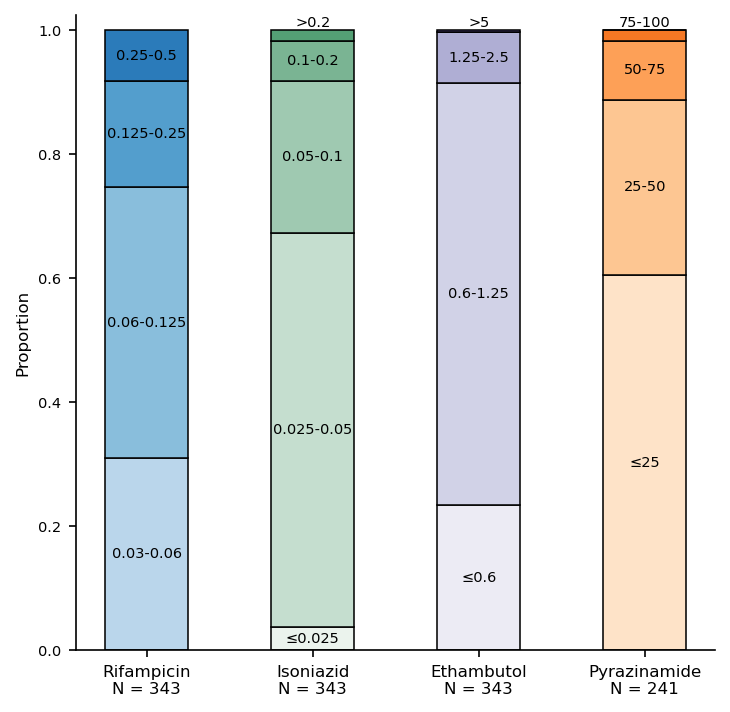

In [38]:
index_var = "Drug"
col_var = "MIC_group"
count_var = "Count"
x_order = ["Rifampicin", "Isoniazid", "Ethambutol", "Pyrazinamide"]

df_stacked_for_plotting = create_stacked_percent_bar_chart(TRUST_plot_phenos, 
                                                           x_order, 
                                                           palettes=[sns.color_palette("Blues").as_hex(),
                                                                     sns.light_palette("seagreen").as_hex(),
                                                                     sns.color_palette("Purples").as_hex(),
                                                                     sns.color_palette("Oranges").as_hex(),
                                                                    ],
                                                           index_var="Drug", 
                                                           col_var="MIC_group", 
                                                           count_var="Count",
                                                           saveName="results/TRUST_phenos_barchart.svg"
                                                          )

In [39]:
def get_TRUST_predicted_and_actual_MICs(drug, model_path, MIC_encoding_dict):

    mic_col = drug #f"s_{drug.lower()}mic_sputum_specimen_1"
    method_col = f"{drug}_method"
    MIC_encoding_dict_rev = {val: key for key, val in MIC_encoding_dict.items()}

    df_TRUST_MICs = get_all_available_MICs_single_drug(drug)
    df_TRUST_predict = pd.read_csv(f"/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/{model_path}/TRUST/test_predictions.csv")

    # normalize the MICs to 7H10 if the MGIT MIC is different from the 7H10 MIC
    drug_full_name = abbr_drug_dict[drug]

    df_TRUST_predict = df_TRUST_predict.merge(df_TRUST_MICs[['SampleID', mic_col, method_col]], left_on='ROLLINGDB_ID', right_on='SampleID')

    # keep only patients with measured MICs, remove samples with a high F2 score
    # keep all WGS runs, even though multiple WGS runs map to a single pid (a single patient's sample has been sequenced multiple times)
    df_TRUST_predict = df_TRUST_predict[['ROLLINGDB_ID', 'log2_pred_MIC', 'pred_MIC']].merge(df_TRUST_MICs[['SampleID', 'pid', 'F2', 'Coll2014', mic_col, method_col]], left_on='ROLLINGDB_ID', right_on='SampleID').query("F2 <= 0.05")

    # convert the MIC categorical variable to a lower bound and upper bound
    df_TRUST_predict[[f"{drug}_lower_bound", f"{drug}_upper_bound"]] = df_TRUST_predict[mic_col].map(MIC_encoding_dict).str.split(",", expand=True).astype(float)

    # CNN PZA MICs were in MGIT
    if drug != 'PZA':

        # these were the only two methods used (7H10 = agar proportion method)
        cc_7H10 = cc_df.query("Drug==@drug_full_name & Medium == '7H10'")['Value'].values[0]
        cc_MGIT = cc_df.query("Drug==@drug_full_name & Medium == 'MGIT'")['Value'].values[0]

        # normalize everything to MGIT because that's the majority scale
        df_TRUST_predict['MGIT_CC'] = cc_MGIT
        df_TRUST_predict['measured_CC'] = df_TRUST_predict[method_col].map({'7H10': cc_7H10, 'MGIT': cc_MGIT})
        
        # normalize from 7H10 (predictions) to MGIT
        df_TRUST_predict['pred_MIC'] *= cc_MGIT / cc_7H10
        
        # make sure all measured MICs are in MGIT, so the INH 7H10 ones need to be converted
        df_TRUST_predict[f"{drug}_lower_bound"] *= df_TRUST_predict['MGIT_CC'] / df_TRUST_predict['measured_CC']
        df_TRUST_predict[f"{drug}_upper_bound"] *= df_TRUST_predict['MGIT_CC'] / df_TRUST_predict['measured_CC']

        # because in the models, we normalized MICs first, then log2-transformed, to get the inverse, we first exponentiate (so take the pred_MIC column), then normalize to get raw MICs. 
        df_TRUST_predict['log2_pred_MIC'] = np.log2(df_TRUST_predict['pred_MIC'])

    df_TRUST_predict[f"{drug}_midpoint"] = np.mean(df_TRUST_predict[[f'{drug}_lower_bound', f'{drug}_upper_bound']], axis=1)

    print(f"{df_TRUST_predict.SampleID.nunique()} WGS samples with F2 ≤ 0.05 across {df_TRUST_predict.pid.nunique()} pids tested in {df_TRUST_predict[method_col].unique()} media")

    # get the range of predicted MICs for the same pid
    df_predicted_MICs_per_pid = df_TRUST_predict.groupby('pid')['pred_MIC'].agg(['min', 'max']).reset_index().merge(pd.DataFrame(df_TRUST_predict.groupby('pid')[drug].nunique()).reset_index())
    df_predicted_MICs_per_pid['diff'] = df_predicted_MICs_per_pid['max'] - df_predicted_MICs_per_pid['min']
    df_predicted_MICs_per_pid.rename(columns={drug: 'num_predicted_MIC_bins'}, inplace=True)
    
    print(f"{len(df_predicted_MICs_per_pid.query('diff > 0'))} pids have multiple predicted MICs")
    print(f"    {len(df_predicted_MICs_per_pid.loc[df_predicted_MICs_per_pid['num_predicted_MIC_bins'] > 1])} have different MIC bin predictions")
    print(f"    Maximum difference in predictions: {np.round(df_predicted_MICs_per_pid.query('diff > 0')['diff'].max(), 4)} µg/mL")

    # add the columns from df_predicted_MICs_per_pid to df_TRUST_predict
    df_TRUST_predict = df_TRUST_predict.merge(df_predicted_MICs_per_pid[['pid', 'min', 'max', 'num_predicted_MIC_bins', 'diff']], how='left', on='pid')

    # deduplicate, keeping only the unique pids. This is because the different sequencing runs from the same pid never have predictions in different bins
    # keep the earliest point
    if len(df_predicted_MICs_per_pid.loc[df_predicted_MICs_per_pid['num_predicted_MIC_bins'] > 1]) == 0:
        df_TRUST_predict = df_TRUST_predict.sort_values(['pid', 'SampleID']).drop_duplicates(subset='pid', keep='first')
        print(f"Keeping only {len(df_TRUST_predict)} unique pids")
    
    return df_TRUST_predict

In [40]:
def compare_predicted_actual_MIC(drug, model_path, MIC_encoding_dict, label_encoding_dict, palette="Blues", model="CNN", saveName=None):

    if model not in ["CNN", "Reg"]:
        raise ValueError(f"{model} must be 'CNN' or 'Reg'")
        
    df_patient_data = get_TRUST_predicted_and_actual_MICs(drug, model_path, MIC_encoding_dict)

    # compute binned mae. Don't need mse and within_doubling
    mae, _, _ = boundedLoss_predict(df_patient_data, y_pred_col="log2_pred_MIC", lower_bounds_col=f"{drug}_lower_bound", upper_bounds_col=f"{drug}_upper_bound")

    mic_col = "pred_MIC"
    plot_col = "pred_MIC_group"
    
    for group, bounds_str in MIC_encoding_dict.items():
    
        lower_bound, upper_bound = np.array(bounds_str.split(",")).astype(float)
        df_patient_data.loc[(df_patient_data[mic_col] > lower_bound) & (df_patient_data[mic_col] <= upper_bound), plot_col] = group

    var1_categories = df_patient_data[drug].unique()
    var2_categories = df_patient_data[plot_col].unique()
    categories = list(MIC_encoding_dict.keys()) #list(set(var1_categories).union(var2_categories))

    overlap = pd.crosstab(df_patient_data[drug], df_patient_data[plot_col])

    # reverse the y-ticks (index) because by default they are increasing DOWN, but we want them to increase UP
    overlap = overlap.reindex(index=categories[::-1], columns=categories, fill_value=0)
    
    # Create the heatmap
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(overlap, annot=True, cmap=palette, linewidths=0.25, linecolor="black", ax=ax, clip_on=False, fmt='g')
    
    old_labels = [float(val.get_text()) for val in ax.get_xticklabels()]
    new_labels = pd.Series(old_labels).map(label_encoding_dict)
    
    ax.set_xticks(ticks=ax.get_xticks(), labels=new_labels, fontsize="7")

    # reverse the y-ticks because by default they are increasing DOWN, but we want them to increase UP
    ax.set_yticks(ticks=ax.get_yticks(), labels=new_labels[::-1], rotation=0, fontsize="7")
    
    plt.xlabel("\nPredicted MIC (µg/mL)", fontsize="10")
    plt.ylabel("Actual MIC (µg/mL)", fontsize="10")
    
    sns.despine()

    predicted_correct = df_patient_data.query(f"{drug} == {plot_col}").shape[0]
    predicted_EA = df_patient_data.query(f"~(({drug} - {plot_col} > 1) | ({plot_col} - {drug} > 1))").shape[0]

    plt.title(f"Categorical Accuracy: {np.round(predicted_correct / len(df_patient_data) * 100, 1)}%\nEsssential Agreement: {np.round(predicted_EA / len(df_patient_data) * 100, 1)}%\nMean Absolute Error: {np.round(mae, 2)} log2-MIC")

    if saveName is None:
        plt.show()
    else:
        if not os.path.isdir(os.path.dirname(saveName)):
            os.makedirs(os.path.dirname(saveName))
        plt.savefig(saveName, bbox_inches="tight")

    return df_patient_data

# Rifampicin

554 WGS samples with F2 ≤ 0.05 across 343 pids tested in ['MGIT'] media
16 pids have multiple predicted MICs
    0 have different MIC bin predictions
    Maximum difference in predictions: 0.0175 µg/mL
Keeping only 343 unique pids


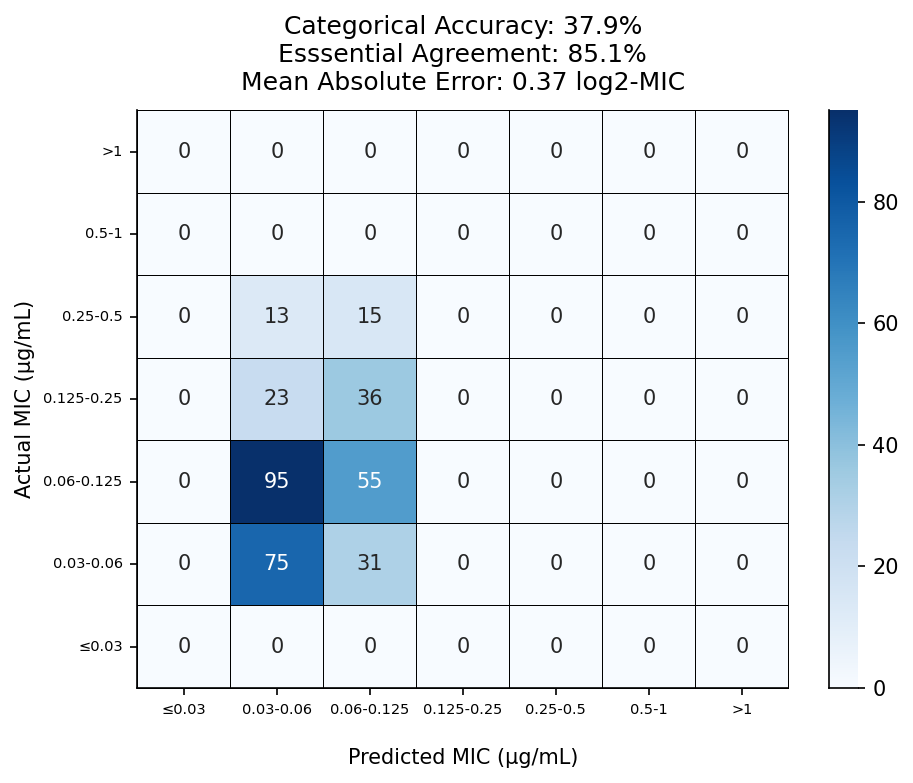

In [41]:
drug = "RIF"
model_path = "RIF_lineage_amino_acid"

RIF_pred = compare_predicted_actual_MIC(drug, model_path, RIF_MIC_encoding_dict, RIF_label_encoding_dict, palette=sns.color_palette("Blues", as_cmap=True), model="CNN",saveName=f"results/{abbr_drug_dict[drug]}/TRUST_CNN_predictions_heatmap.svg")

In [72]:
RIF_pred_TCC = df_TCC[['pid', 'culture_convert', 'TCC']].merge(RIF_pred)[['pid', 'culture_convert', 'TCC', 'pred_MIC', 'log2_pred_MIC', 'RIF', 'RIF_lower_bound', 'RIF_midpoint', 'RIF_upper_bound', 'pred_MIC_group']]

In [75]:
# predicted MIC
st.spearmanr(RIF_pred_TCC['RIF'], RIF_pred_TCC['TCC'])

SignificanceResult(statistic=-0.15121453987906378, pvalue=0.005008841547962622)

In [76]:
# predicted MIC
st.spearmanr(RIF_pred_TCC['pred_MIC_group'], RIF_pred_TCC['TCC'])

SignificanceResult(statistic=-0.12519784256893582, pvalue=0.020375249235075575)

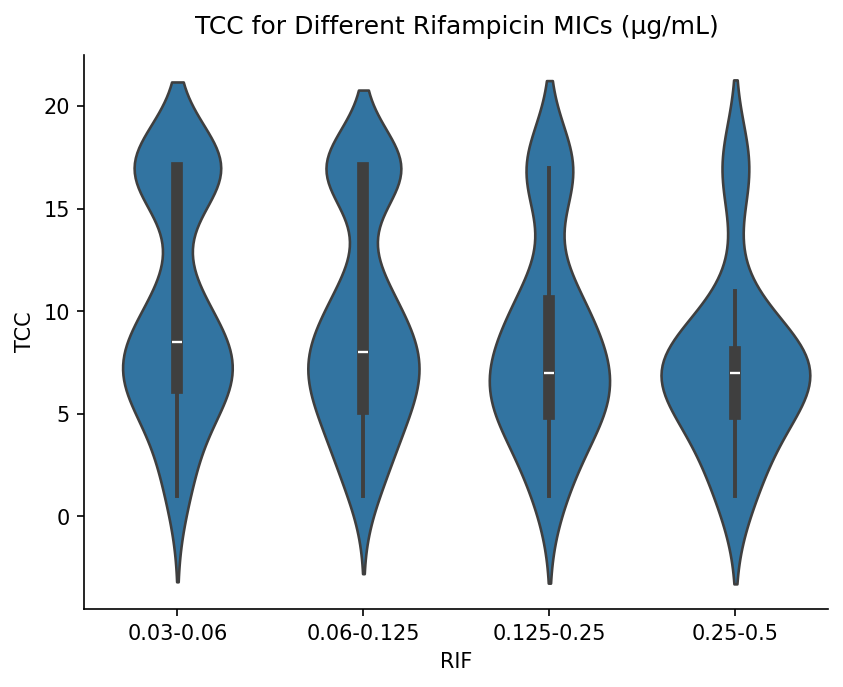

In [68]:
fig, ax = plt.subplots()

sns.violinplot(data=RIF_pred_TCC,
              x='RIF',
              y='TCC',
            ax=ax
             )

ax.set_xticks(ticks=ax.get_xticks(), labels=[RIF_label_encoding_dict[int(float(val.get_text()))] for val in ax.get_xticklabels()])

plt.title("TCC for Different Rifampicin MICs (µg/mL)")

sns.despine()
plt.show()

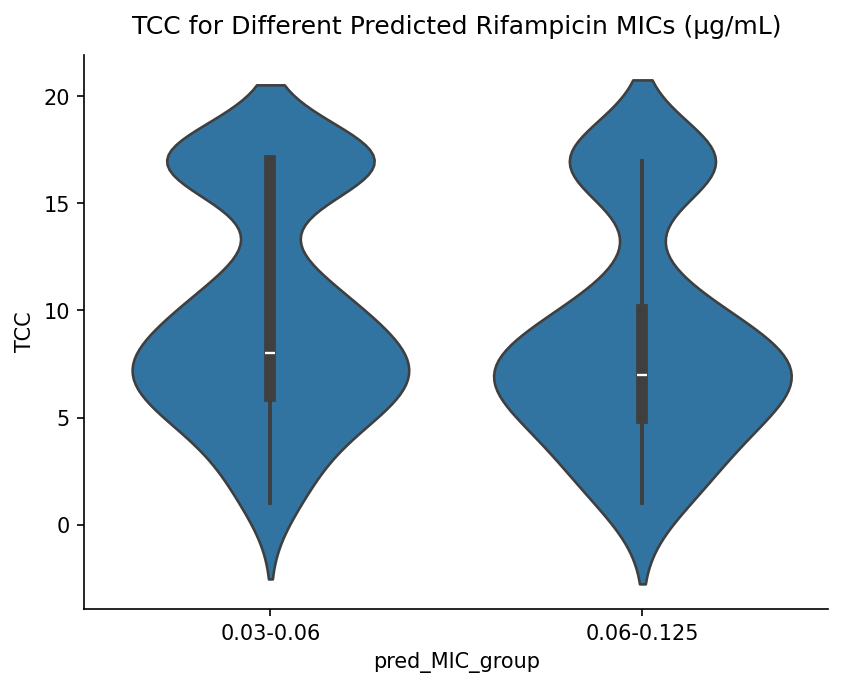

In [77]:
fig, ax = plt.subplots()

sns.violinplot(data=RIF_pred_TCC,
              x='pred_MIC_group',
              y='TCC',
            ax=ax
             )

ax.set_xticks(ticks=ax.get_xticks(), labels=[RIF_label_encoding_dict[int(float(val.get_text()))] for val in ax.get_xticklabels()])

plt.title("TCC for Different Predicted Rifampicin MICs (µg/mL)")

sns.despine()
plt.show()

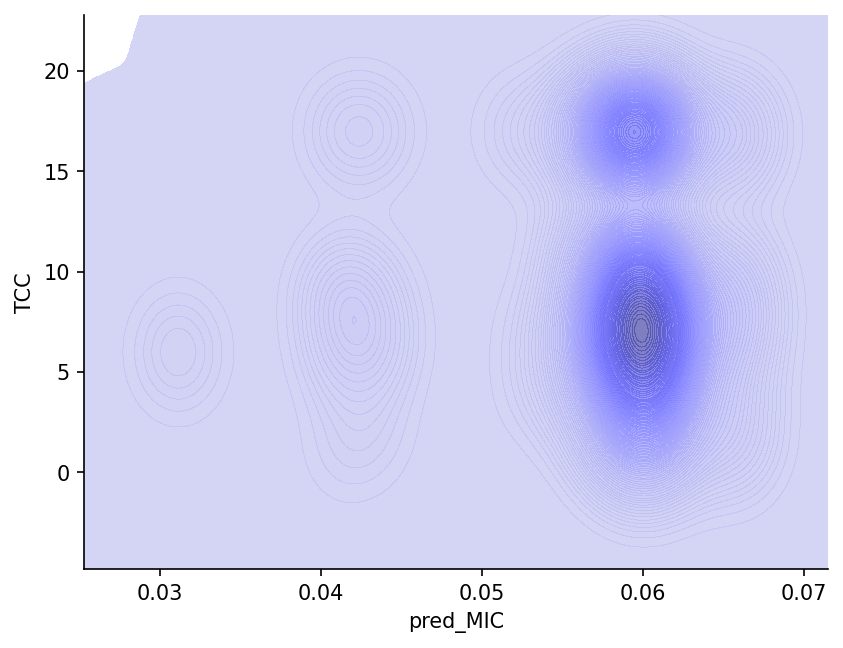

In [49]:
# sns.scatterplot(data=RIF_pred_TCC,
#               x='pred_MIC',
#               y='TCC'
#              )

sns.kdeplot(data=RIF_pred_TCC, x='pred_MIC', y='TCC', fill=True, thresh=0, levels=100, color='b', alpha=0.7)

sns.despine()
plt.show()

In [69]:
RIF_pred_TCC#.query("culture_convert==0")

,pid,culture_convert,TCC,pred_MIC,log2_pred_MIC,RIF,RIF_lower_bound,RIF_midpoint,RIF_upper_bound
0,T0001,1,1,0.060793,-4.039948,3.0,0.060,0.0925,0.125
1,T0002,1,5,0.059695,-4.066239,3.0,0.060,0.0925,0.125
2,T0003,1,10,0.060603,-4.044477,2.0,0.030,0.0450,0.060
3,T0004,0,17,0.059484,-4.071358,3.0,0.060,0.0925,0.125
4,T0005,1,10,0.059484,-4.071358,3.0,0.060,0.0925,0.125
...,...,...,...,...,...,...,...,...,...
338,T0451,1,5,0.060603,-4.044477,4.0,0.125,0.1875,0.250
339,T0452,1,4,0.056847,-4.136768,3.0,0.060,0.0925,0.125
340,T0453,1,7,0.060603,-4.044477,4.0,0.125,0.1875,0.250
341,T0455,1,8,0.060648,-4.043394,3.0,0.060,0.0925,0.125


In [129]:
# measured MIC
st.spearmanr(RIF_pred_TCC['RIF_midpoint'], RIF_pred_TCC['TCC'])

SignificanceResult(statistic=-0.15121453987906378, pvalue=0.005008841547962622)

In [125]:
st.spearmanr(RIF_pred_TCC.query("culture_convert==1")['pred_MIC'], RIF_pred_TCC.query("culture_convert==1")['TCC'])

SignificanceResult(statistic=-0.07789121096292438, pvalue=0.21787059538465678)

In [126]:
st.spearmanr(RIF_pred_TCC.query("culture_convert==1")['RIF_midpoint'], RIF_pred_TCC.query("culture_convert==1")['TCC'])

SignificanceResult(statistic=-0.05581688596811626, pvalue=0.3775883987443255)

In [ ]:
df_trust_patients

In [134]:
df_trust_patients#.query("")

,pid,screen_version,screen_date,screen_ic,screen_icdate,screen_parentic___1,screen_icversion,screen_reenroll,screen_prevpid,screen_sex,...,transfered_pcrfree,transfered_pacbio,shipment,status,comment,Coll2014_Annotated,sample_week,VCF,F2,Coll2014
0,T0001,13.0,0,1,0,0,3.2,NaN,NaN,1,...,NaN,NaN,3rd,finished,-,4.3.2.1 LAM,1,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.010307,4.3.2.1
1,T0002,NaN,0,1,0,0,3.2,NaN,NaN,2,...,NaN,NaN,NaN,NaN,NaN,NaN,1,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.006462,4.8
2,T0002,NaN,0,1,0,0,3.2,NaN,NaN,2,...,1.0,NaN,NaN,NaN,NaN,NaN,5,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.007868,4.8
3,T0003,NaN,0,1,0,0,3.2,NaN,NaN,2,...,NaN,NaN,NaN,NaN,NaN,NaN,1,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.009638,2.2.1
4,T0003,NaN,0,1,0,0,3.2,NaN,NaN,2,...,1.0,NaN,NaN,NaN,NaN,NaN,8,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.010143,2.2.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
584,T0451,13.0,0,1,0,0,8.3,1.0,T0039,1,...,1.0,NaN,NaN,NaN,NaN,NaN,1,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.010235,2.2.1.1
585,T0452,13.0,0,1,0,0,8.3,0.0,NaN,2,...,NaN,NaN,NaN,NaN,NaN,NaN,1,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.005678,4.3.3
586,T0453,13.0,0,1,0,0,8.3,1.0,T0290,1,...,1.0,NaN,NaN,NaN,NaN,NaN,1,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.009453,2.2.1.1
587,T0455,13.0,0,1,0,0,8.3,0.0,NaN,1,...,1.0,NaN,NaN,NaN,NaN,NaN,1,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.019831,4.1.1.2


In [88]:
st.spearmanr(RIF_pred_TCC['pred_MIC'], RIF_pred_TCC['TCC'])

SignificanceResult(statistic=-0.09426022597558435, pvalue=0.16549544646867143)

In [54]:
isolates_with_RIF_R_variants = isolate_variants.query("ROLLINGDB_ID in @RIF_pred.ROLLINGDB_ID & drug=='Rifampicin' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim']").ROLLINGDB_ID.unique()

len(isolates_with_RIF_R_variants)

0

In [238]:
isolate_variants.query("ROLLINGDB_ID in @RIF_pred.ROLLINGDB_ID & drug=='Rifampicin' & GENE in ['rpoB', 'rpoC']")[['variant', 'confidence']].value_counts()

variant           confidence                
rpoB_c.3225T>C    5) Not assoc w R              200
rpoC_c.1626C>G    5) Not assoc w R               65
rpoC_p.Gly594Glu  5) Not assoc w R               59
rpoB_c.2628T>G    5) Not assoc w R               23
rpoC_c.2701C>T    5) Not assoc w R               20
rpoB_c.309C>T     5) Not assoc w R               12
rpoB_c.390C>T     4) Not assoc w R - Interim      7
rpoC_p.Thr225Asn  3) Uncertain significance       6
rpoC_c.186C>T     4) Not assoc w R - Interim      5
rpoC_p.Asp271Gly  5) Not assoc w R                4
rpoB_p.Glu738Ala  3) Uncertain significance       2
rpoB_p.Val113Ile  3) Uncertain significance       2
rpoC_c.894G>A     5) Not assoc w R                2
rpoC_p.Pro601Leu  5) Not assoc w R                1
rpoB_c.1683G>A    5) Not assoc w R                1
rpoC_p.Ala172Val  5) Not assoc w R                1
rpoC_c.517C>A     5) Not assoc w R                1
rpoC_c.2619G>A    4) Not assoc w R - Interim      1
rpoC_c.1929G>A    4

In [232]:
rpo_synonymous_variants = isolate_variants.query("EFFECT == 'synonymous_variant' & GENE in ['rpoB', 'rpoC']").merge(RIF_pred, how='right')
rpo_synonymous_variants.GENE.unique()

array(['rpoC', nan, 'rpoB'], dtype=object)

In [233]:
rpo_synonymous_variants.loc[(rpo_synonymous_variants['AF'] > 0.75) &
                            (rpo_synonymous_variants['DP'] >= 5) & 
                            (rpo_synonymous_variants['MQ'] >= 30) & 
                            (rpo_synonymous_variants['BQ'] >= 20) &
                            (rpo_synonymous_variants['QUAL'] >= 10), 'VARIANTS'
                           ] = 1

rpo_synonymous_variants['VARIANTS'] = rpo_synonymous_variants['VARIANTS'].fillna(0).astype(int)

In [234]:
rpo_synonymous_variants_counts = pd.DataFrame(rpo_synonymous_variants.groupby(['ROLLINGDB_ID'])['VARIANTS'].sum()).reset_index()
rpo_synonymous_variants_counts = rpo_synonymous_variants_counts.merge(rpo_synonymous_variants[['ROLLINGDB_ID', 'RIF']])

In [235]:
rpo_synonymous_variants_counts.VARIANTS.unique()

array([1, 0, 2, 3])

In [236]:
# significant negative correlation between # of variants and measured MIC, so more variants tends to lead to susceptibility.
# holds for rpoB only, rpoB + rpoC, and rpoB + rpoC + rpoA
st.spearmanr(rpo_synonymous_variants_counts['VARIANTS'], rpo_synonymous_variants_counts['RIF'])

SignificanceResult(statistic=-0.2735555648934163, pvalue=4.018977842749528e-08)

# Isoniazid

554 WGS samples with F2 ≤ 0.05 across 343 pids tested in ['7H10' 'MGIT'] media
17 pids have multiple predicted MICs
    0 have different MIC bin predictions
    Maximum difference in predictions: 0.0184 µg/mL
Keeping only 343 unique pids


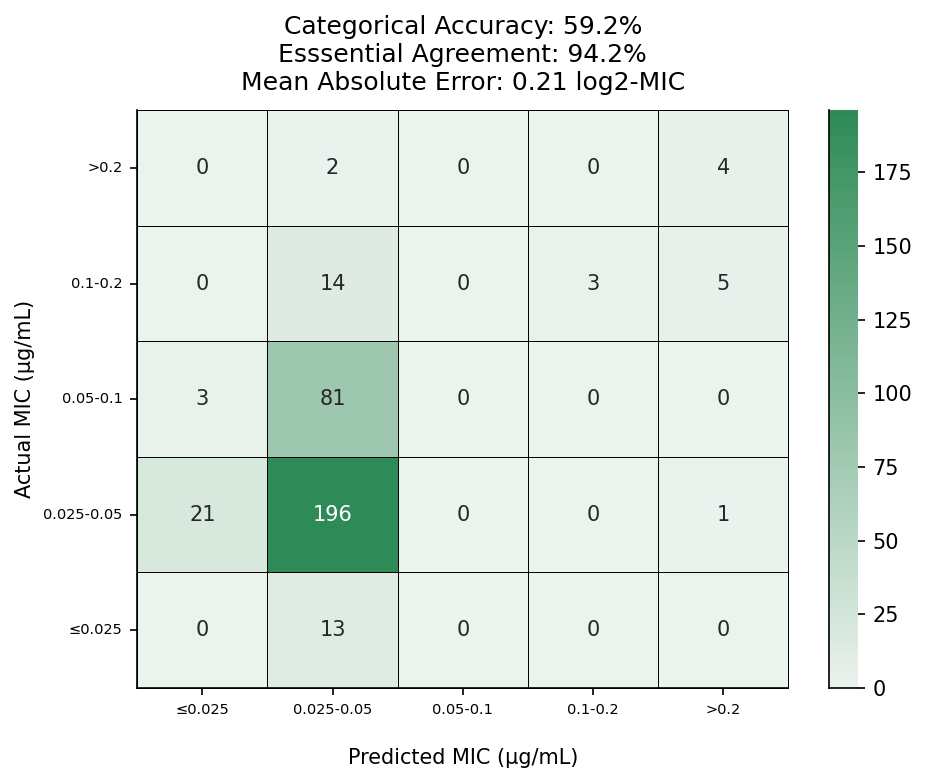

In [78]:
drug = "INH"
model_path = "INH_lineage_amino_acid"

INH_pred = compare_predicted_actual_MIC(drug, model_path, INH_MIC_encoding_dict, INH_label_encoding_dict, palette=sns.light_palette("seagreen", as_cmap=True), model="CNN", saveName=f"results/{abbr_drug_dict[drug]}/TRUST_CNN_predictions_heatmap.svg")

In [73]:
INH_pred = df_TCC_for_corr.merge(INH_pred)
st.spearmanr(INH_pred['pred_MIC'], INH_pred['TCC'])

SignificanceResult(statistic=0.06992771085254643, pvalue=0.30404711971160714)

In [ ]:
There are three underpredicted isolates -- the measured INH MIC is >0.2 µg/mL and the predicted MIC is less than 0.1: MFS-15, MFS-397, MFS-398. I've attached a list of variants in these isolates that are either in the catalog associated with isoniazid or not in the catalog at all (they are NaN in the drug and confidence columns).

There are two overpredicted isolates -- the measured INH MIC is 0.025-0.05 µg/mL and the predicted MIC is >0.2: MFS-360 and MFS-361. Both have inhA_c.-777C>T. 

In [183]:
INH_pred.query("INH==5 & pred_MIC_group < 4")

,pid,INH_lower_bound,INH_upper_bound,INH_midpoint,ROLLINGDB_ID,log2_pred_MIC,pred_MIC,SampleID,F2,Coll2014,...,7H10_CC,measured_CC,min,max,num_predicted_MIC_bins,diff,log2_pred_MIC_exp,within_doubling,compute_error,pred_MIC_group
60,T0030,0.2,100000.0,50000.1,MFS-15,-4.304075,0.050623,MFS-15,0.014397,3,...,0.2,0.2,0.050623,0.050623,1,0.000000,0.05,0,1,3.0
248,T0331,0.2,100000.0,50000.1,MFS-397,-4.975218,0.031791,MFS-397,0.009786,2.2.1,...,0.2,0.1,0.025146,0.031791,1,0.006646,0.03,0,1,2.0


In [184]:
INH_pred.query("INH < 4 & pred_MIC_group == 5")

,pid,INH_lower_bound,INH_upper_bound,INH_midpoint,ROLLINGDB_ID,log2_pred_MIC,pred_MIC,SampleID,F2,Coll2014,...,7H10_CC,measured_CC,min,max,num_predicted_MIC_bins,diff,log2_pred_MIC_exp,within_doubling,compute_error,pred_MIC_group
218,T0108,0.025,0.05,0.0375,MFS-360,-2.127062,0.228924,MFS-360,0.010495,2.2.1,...,0.2,0.1,0.228924,0.228924,1,0.0,0.23,0,1,5.0


In [65]:
send_df = isolate_variants.query("ROLLINGDB_ID in ['MFS-397', 'MFS-15'] & EFFECT not in @silent_lst").loc[(isolate_variants['drug']=='Isoniazid') | (pd.isnull(isolate_variants['drug']))].drop_duplicates(subset=['ROLLINGDB_ID', 'POS', 'REF', 'ALT', 'FILTER', 'AF'], keep='last')[['ROLLINGDB_ID', 'variant', 'drug', 'confidence', 'FILTER', 'AF']]

send_df

,ROLLINGDB_ID,variant,drug,confidence,FILTER,AF
2748,MFS-15,katG_p.Arg463Leu,Isoniazid,5) Not assoc w R,PASS,1.00
2754,MFS-15,ahpC_c.-88G>A,Isoniazid,5) Not assoc w R,PASS,0.98
2781,MFS-15,Rv3863_c.-253delC,NaN,NaN,PASS,1.00
11584,MFS-397,mshA_p.Ala187Val,Isoniazid,5) Not assoc w R,PASS,1.00
11598,MFS-397,Rv1258c_p.Glu194fs,Isoniazid,5) Not assoc w R,PASS,1.00
11604,MFS-397,katG_p.Ala706Glu,NaN,NaN,Amb,0.32
11605,MFS-397,katG_p.Arg463Leu,Isoniazid,5) Not assoc w R,PASS,1.00
11606,MFS-397,katG_p.Trp438Arg,NaN,NaN,Amb,0.28
11610,MFS-397,kefB_p.Thr102Ala,NaN,NaN,PASS,1.00
11622,MFS-397,Rv3863_c.-253delC,NaN,NaN,PASS,1.00


In [50]:
# send_df.to_csv("TRUST_isolates_INH_variants.csv", index=False)

In [68]:
isolate_variants.query("ROLLINGDB_ID in ['MFS-360'] & EFFECT not in @silent_lst").loc[(isolate_variants['drug']=='Isoniazid') | (pd.isnull(isolate_variants['drug']))].drop_duplicates(subset=['ROLLINGDB_ID', 'POS', 'REF', 'ALT', 'FILTER', 'AF'], keep='last')[['ROLLINGDB_ID', 'variant', 'drug', 'confidence', 'FILTER', 'AF', 'QUAL', 'BQ', 'MQ']]

,ROLLINGDB_ID,variant,drug,confidence,FILTER,AF,QUAL,BQ,MQ
10103,MFS-360,mshA_p.Ala187Val,Isoniazid,5) Not assoc w R,PASS,1.00,6456.0,33.0,60.0
10119,MFS-360,Rv0678_c.-11C>A,NaN,NaN,PASS,1.00,8921.0,33.0,60.0
10121,MFS-360,Rv1129c_p.Ser77Tyr,Isoniazid,3) Uncertain significance,PASS,1.00,9305.0,33.0,60.0
10123,MFS-360,Rv1258c_p.Glu194fs,Isoniazid,5) Not assoc w R,PASS,0.99,7793.0,33.0,60.0
10128,MFS-360,inhA_c.-777C>T,Isoniazid,1) Assoc w R,PASS,1.00,8261.0,33.0,60.0
10132,MFS-360,katG_p.Arg463Leu,Isoniazid,5) Not assoc w R,PASS,1.00,7567.0,33.0,60.0
10136,MFS-360,kefB_p.Thr102Ala,NaN,NaN,PASS,1.00,8097.0,33.0,60.0
10148,MFS-360,Rv3863_c.-253delC,NaN,NaN,PASS,1.00,0.0,0.0,60.0


# Ethambutol

554 WGS samples with F2 ≤ 0.05 across 343 pids tested in ['MGIT'] media
18 pids have multiple predicted MICs
    0 have different MIC bin predictions
    Maximum difference in predictions: 0.617 µg/mL
Keeping only 343 unique pids


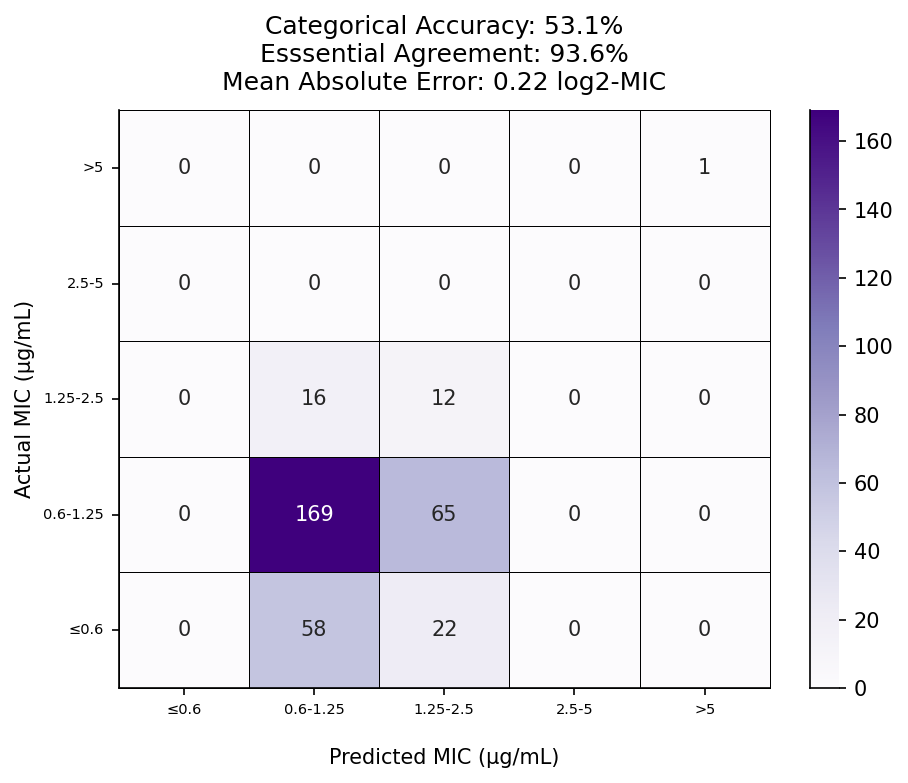

In [79]:
drug = "EMB"
model_path = "EMB_lineage_amino_acid"

EMB_pred = compare_predicted_actual_MIC(drug, model_path, EMB_MIC_encoding_dict, EMB_label_encoding_dict, palette=sns.color_palette("Purples", as_cmap=True), model="CNN", saveName=f"results/{abbr_drug_dict[drug]}/TRUST_CNN_predictions_heatmap.svg")

In [74]:
EMB_pred = df_TCC_for_corr.merge(EMB_pred)
st.spearmanr(EMB_pred['pred_MIC'], EMB_pred['TCC'])

SignificanceResult(statistic=-0.11139129874197592, pvalue=0.10093736649229834)

In [539]:
isolates_with_EMB_R_variants = isolate_variants.query("ROLLINGDB_ID in @EMB_pred.ROLLINGDB_ID & drug=='Ethambutol' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim']").ROLLINGDB_ID.unique()

len(isolates_with_EMB_R_variants)

2

In [652]:
EMB_overpredicted = EMB_pred.query("pred_MIC_group==3 & EMB==1")
EMB_overpredicted.shape

(6, 20)

In [653]:
abbr_drug_dict

{'DLM': 'Delamanid',
 'BDQ': 'Bedaquiline',
 'CFZ': 'Clofazimine',
 'ETH': 'Ethionamide',
 'LZD': 'Linezolid',
 'MXF': 'Moxifloxacin',
 'CAP': 'Capreomycin',
 'AMI': 'Amikacin',
 'PTM': 'Pretomanid',
 'PZA': 'Pyrazinamide',
 'KAN': 'Kanamycin',
 'LEV': 'Levofloxacin',
 'STM': 'Streptomycin',
 'EMB': 'Ethambutol',
 'INH': 'Isoniazid',
 'RIF': 'Rifampicin'}

In [176]:
set_1 = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/vcf_full_paths.txt", sep='\t', header=None)[0].values
set_2 = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/vcf_full_paths_filtered.txt", sep='\t', header=None)[0].values

In [177]:
set(set_1) - set(set_2)

{'/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/VCF/MFS-370.vcf',
 '/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/VCF/MFS-371.vcf'}

In [655]:
isolate_variants.query("ROLLINGDB_ID in @EMB_overpredicted.SampleID.values").loc[(isolate_variants['drug']=='Ethambutol')]#.variant.value_counts()

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
788,MFS-118,4242643,C,T,PASS,7847.0,False,1.0,242.0,32.0,60.0,0.0,0.0,synonymous_variant,embC,c.2781C>T,p.Arg927Arg,embC_c.2781C>T,Ethambutol,5) Not assoc w R
2313,MFS-150,4242643,C,T,PASS,9397.0,False,1.0,291.0,32.0,60.0,0.0,0.0,synonymous_variant,embC,c.2781C>T,p.Arg927Arg,embC_c.2781C>T,Ethambutol,5) Not assoc w R
2343,MFS-151,4242643,C,T,PASS,8594.0,False,1.0,270.0,32.0,60.0,0.0,0.0,synonymous_variant,embC,c.2781C>T,p.Arg927Arg,embC_c.2781C>T,Ethambutol,5) Not assoc w R
4556,MFS-258,4242643,C,T,PASS,9610.0,False,1.0,320.0,31.0,60.0,0.0,0.0,synonymous_variant,embC,c.2781C>T,p.Arg927Arg,embC_c.2781C>T,Ethambutol,5) Not assoc w R
4878,MFS-265,4242643,C,T,PASS,7082.0,False,1.0,237.0,31.0,60.0,0.0,0.0,synonymous_variant,embC,c.2781C>T,p.Arg927Arg,embC_c.2781C>T,Ethambutol,5) Not assoc w R
17803,MFS-541,4242643,C,T,PASS,7877.0,False,1.0,250.0,32.0,60.0,0.0,0.0,synonymous_variant,embC,c.2781C>T,p.Arg927Arg,embC_c.2781C>T,Ethambutol,5) Not assoc w R


In [650]:
EMB_overpredicted['Coll2014'].value_counts()

Coll2014
4.3.2.1      10
4.4.1.1       9
4.1.2.1       5
4.3.4.2.1     4
4.3.3         3
4.8           2
2.2.1         2
Name: count, dtype: int64

In [647]:
# isolate_variants.query("ROLLINGDB_ID in @EMB_overpredicted.SampleID.values").loc[(isolate_variants['drug']=='Ethambutol')]

In [644]:
search_variants = isolate_variants.query("ROLLINGDB_ID in @EMB_overpredicted.SampleID.values").loc[(isolate_variants['drug']=='Ethambutol')].variant.values

In [642]:
insilico_pred = pd.read_csv("results/tables/insilico_pred_all.csv")

In [645]:
insilico_pred.query("variant in @search_variants")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
1111,aftB_p.Asp397Gly,0.309920,1.239639,missense_variant,5.0,aftB-ubiA,5) Not assoc w R,1.246963,0.994127,-0.008498,aftB,Ethambutol
1581,embA_c.228C>T,0.317973,1.246578,synonymous_variant,5.0,aftA-embCAB,5) Not assoc w R,1.246963,0.999691,-0.000446,embA,Ethambutol
4449,embC_c.2781C>T,0.332155,1.258893,synonymous_variant,5.0,aftA-embCAB,5) Not assoc w R,1.246963,1.009567,0.013737,embC,Ethambutol
5133,embC_p.Val981Leu,0.299332,1.230575,missense_variant,5.0,aftA-embCAB,5) Not assoc w R,1.246963,0.986858,-0.019086,embC,Ethambutol


In [639]:
isolate_variants.query("ROLLINGDB_ID in @EMB_overpredicted.SampleID.values").loc[(pd.isnull(isolate_variants['drug'])) | (isolate_variants['drug']=='Ethambutol')]

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
376,MFS-10,1475407,C,T,PASS,12872.0,False,1.00,390.0,33.0,60.0,0.0,0.0,intragenic_variant,rrl,n.1475407C>T,NaN,rrl_n.1750C>T,NaN,NaN
377,MFS-10,1674334,C,A,PASS,7701.0,False,1.00,229.0,34.0,60.0,0.0,0.0,synonymous_variant,inhA,c.133C>A,p.Arg45Arg,inhA_c.133C>A,NaN,NaN
385,MFS-10,4242643,C,T,PASS,7759.0,False,1.00,238.0,33.0,60.0,0.0,0.0,synonymous_variant,embC,c.2781C>T,p.Arg927Arg,embC_c.2781C>T,Ethambutol,5) Not assoc w R
389,MFS-10,4338595,GC,G,PASS,0.0,False,1.00,353.0,0.0,60.0,0.0,353.0,intergenic_region,whiB6-Rv3863,n.4338596delC,NaN,Rv3863_c.-253delC,NaN,NaN
772,MFS-118,1475403,T,TA,PASS,13838.0,False,0.99,439.0,32.0,60.0,433.0,0.0,intragenic_variant,rrl,n.1475405dupA,NaN,rrl_n.1475405dupA,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24960,MFS-702,4338595,GC,G,PASS,0.0,False,1.00,301.0,0.0,60.0,0.0,301.0,intergenic_region,whiB6-Rv3863,n.4338596delC,NaN,Rv3863_c.-253delC,NaN,NaN
27055,MFS-9,1475407,C,T,PASS,11376.0,False,1.00,346.0,33.0,60.0,0.0,0.0,intragenic_variant,rrl,n.1475407C>T,NaN,rrl_n.1750C>T,NaN,NaN
27056,MFS-9,1674334,C,A,PASS,8093.0,False,1.00,241.0,34.0,60.0,0.0,0.0,synonymous_variant,inhA,c.133C>A,p.Arg45Arg,inhA_c.133C>A,NaN,NaN
27064,MFS-9,4242643,C,T,PASS,6752.0,False,1.00,211.0,32.0,60.0,0.0,0.0,synonymous_variant,embC,c.2781C>T,p.Arg927Arg,embC_c.2781C>T,Ethambutol,5) Not assoc w R


# Pyrazinamide

383 WGS samples with F2 ≤ 0.05 across 241 pids tested in ['MGIT'] media
14 pids have multiple predicted MICs
    0 have different MIC bin predictions
    Maximum difference in predictions: 12.3828 µg/mL
Keeping only 241 unique pids


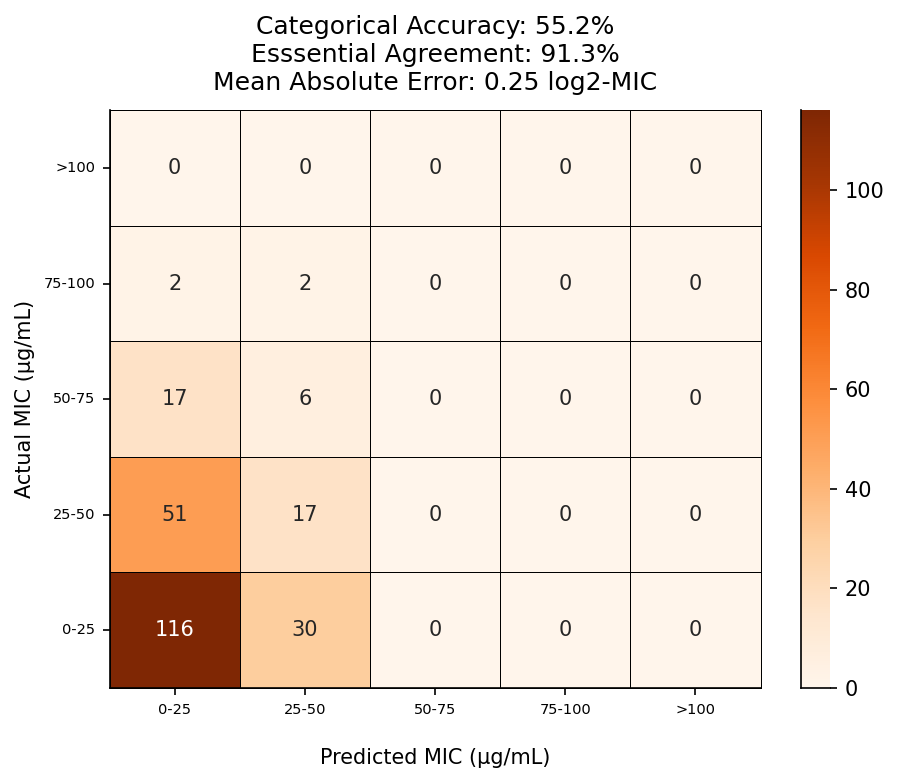

In [80]:
drug = "PZA"
model_path = "PZA_lineage_amino_acid"

PZA_pred = compare_predicted_actual_MIC(drug, model_path, PZA_MIC_encoding_dict, PZA_label_encoding_dict, palette=sns.color_palette("Oranges", as_cmap=True), model="CNN", saveName=f"results/{abbr_drug_dict[drug]}/TRUST_CNN_predictions_heatmap.svg")

In [75]:
PZA_pred = df_TCC_for_corr.merge(PZA_pred)
st.spearmanr(PZA_pred['pred_MIC'], PZA_pred['TCC'])

SignificanceResult(statistic=-0.025645407791023107, pvalue=0.7506463516003897)

In [75]:
isolates_with_PZA_R_variants = isolate_variants.query("ROLLINGDB_ID in @PZA_pred.ROLLINGDB_ID & drug=='Pyrazinamide' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim']").ROLLINGDB_ID.unique()

len(isolates_with_PZA_R_variants)

0

# Distribution of MICs per Unique Sequence

In [260]:
def plot_barplot_mics_per_seq(drug, drug_full_name, mic_label_encoding_dict, saveFig=False):

    drug_col = f"s_{drug.lower()}mic_sputum_specimen_1"
    fasta_files = glob.glob(os.path.join(data_dir, drug, "fastas", "TRUST", "*.fasta"))
    combined_seq_df = []
    
    for fName in fasta_files:
        fasta_seq = [(seq.id.split(".")[0], str(seq.seq)) for seq in SeqIO.parse(fName, "fasta")]
        seq_df = pd.DataFrame(fasta_seq)
        seq_df.columns = ["ROLLINGDB_ID", os.path.basename(fName).split(".")[0]]
        combined_seq_df.append(seq_df)
    
    combined_seq_df = reduce(lambda x, y: pd.merge(x, y, on = 'ROLLINGDB_ID'), combined_seq_df).set_index('ROLLINGDB_ID')
    
    # string concatenate (join) all loci
    combined_seq_df = pd.DataFrame(combined_seq_df.apply(''.join, axis=1))
    combined_seq_df.columns = ['Seq']
    combined_seq_df = combined_seq_df.reset_index()
    
    combined_seq_df = combined_seq_df.merge(df_trust[['ROLLINGDB_ID', 'pid']].merge(df_trust_patients[['pid', drug_col]].dropna(axis=0), on='pid'), left_on='ROLLINGDB_ID', right_on='SampleID')
    del combined_seq_df['ROLLINGDB_ID']
    
    seq_num_mapping = dict(zip(combined_seq_df.Seq.unique(), np.arange(len(combined_seq_df.Seq.unique())).astype(str)))
    combined_seq_df["Seq_Num"] = combined_seq_df["Seq"].map(seq_num_mapping)
    
    _, seq_counts = np.unique(combined_seq_df["Seq_Num"], return_counts=True)

    # minimum number of isolates with a given sequence -- should be at least 2, otherwise there is just a single isolate with an MIC. that would just be clutter
    isolate_thresh = 2
    
    # keep only unique sequences with at least 2 isolates
    # plot_df = combined_seq_df.groupby('Seq_Num').filter(lambda x: len(x) >= isolate_thresh)
    
    # keep only unique sequences with at least 2 different measured MICs
    plot_df = combined_seq_df.groupby('Seq_Num').filter(lambda x: x[drug_col].nunique() >= isolate_thresh)
    
    seq_num_order = plot_df.groupby("Seq_Num")[drug_col].mean().sort_values(ascending=True).index.values
    
    plot_df_matrix = pd.DataFrame(plot_df.groupby('Seq_Num')[drug_col].value_counts()).reset_index().pivot(index="Seq_Num", columns=drug_col, values="count").fillna(0).astype(int)
    plot_df_matrix = plot_df_matrix.loc[seq_num_order]
    
    totals_by_seq_group = plot_df_matrix.sum(axis=1).values

    if drug == 'RIF':
        colors = sns.color_palette("Blues", n_colors=len(plot_df_matrix.columns))
    elif drug == 'PZA':
        colors = sns.color_palette("Oranges", n_colors=len(plot_df_matrix.columns))
    elif drug == 'INH':
        sns.light_palette("seagreen", n_colors=len(plot_df_matrix.columns))
    elif drug == 'EMB':
        colors = sns.light_palette("Purples", n_colors=len(plot_df_matrix.columns))
    
    plot_df_matrix_percents = plot_df_matrix.copy()
    
    # convert to percentages
    for col in plot_df_matrix_percents.columns:
        plot_df_matrix_percents[col] = plot_df_matrix_percents[col] / totals_by_seq_group * 100
        
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    
    # keep track of all the groups to increase the start value of the next bar
    prev_vals_array = np.zeros(len(plot_df_matrix_percents))
    
    for i, mic_group in enumerate(plot_df_matrix_percents.columns):        
                                
        ax.bar(seq_num_order, 
               plot_df_matrix_percents[mic_group], 
               color=colors[i], 
               bottom = prev_vals_array, 
               edgecolor="black",
               linewidth=0.7,
               label=mic_group,
               alpha=0.75,
              )
    
    
        # plot the bar sizes (percentages) and the true counts
        for k, seq_group in enumerate(plot_df_matrix_percents.index.values):
    
            val = plot_df_matrix_percents.loc[seq_group, mic_group]
                
            # bottom of the current box    
            y_lower = plot_df_matrix_percents.loc[seq_group, plot_df_matrix_percents.columns[:i + 1]].values.sum()

            # top of the current box
            y_upper = plot_df_matrix_percents.loc[seq_group, plot_df_matrix_percents.columns[:i]].values.sum()

            y_pos = np.mean([y_lower, y_upper])
    
            if val > 0:
                combined_label = f"{int(np.round(val))}%\n(N={plot_df_matrix.loc[seq_group, mic_group]})"
                
                # small numbers for which the bars are too short to accommodate the whole number, put on top
                if val < 3:
                    ax.text(seq_group, y_pos + 1, combined_label, ha='center', va='bottom', fontsize='8')
                else:
                    ax.text(seq_group, y_pos, combined_label, ha='center', va='center', fontsize='8')
    
        # increment bottom
        prev_vals_array += plot_df_matrix_percents[mic_group]
        
        # adjust legend manually to show the exact MIC ranges with the colors, NOT the integer groups
    
    handles, labels = ax.get_legend_handles_labels()    
    
    # RIF_label_encoding_dict keys are integers, but labels are strings
    mic_labels = [mic_label_encoding_dict[int(float(val))] for val in labels]
    
    # Set the legend handles
    ax.legend(handles, mic_labels)
    plt.xticks([], [])
    ax.margins(x=0.01)
    sns.despine()
    
    sns.move_legend(ax, fontsize=10, title='MIC Range (µg/mL)', loc='upper right', #bbox_to_anchor=(1.05, 0.65),
                    ncol=len(colors),
                   bbox_to_anchor=(0.75, -0.02))
    
    plt.title(f"{drug_full_name} MICs for {len(plot_df)} Isolates across {len(seq_num_order)} Unique Concatenated {len(fasta_files)}-Loci Sequences\n")

    if saveFig:
        plt.savefig(f"TRUST/{drug}_barplot_MICS_by_seq.png", dpi=300, bbox_inches='tight')
    else:
        plt.show()

    return plot_df_matrix

In [261]:
_ = plot_barplot_mics_per_seq("RIF", "Rifampicin", RIF_label_encoding_dict, saveFig=True)

TypeError: reduce() of empty sequence with no initial value

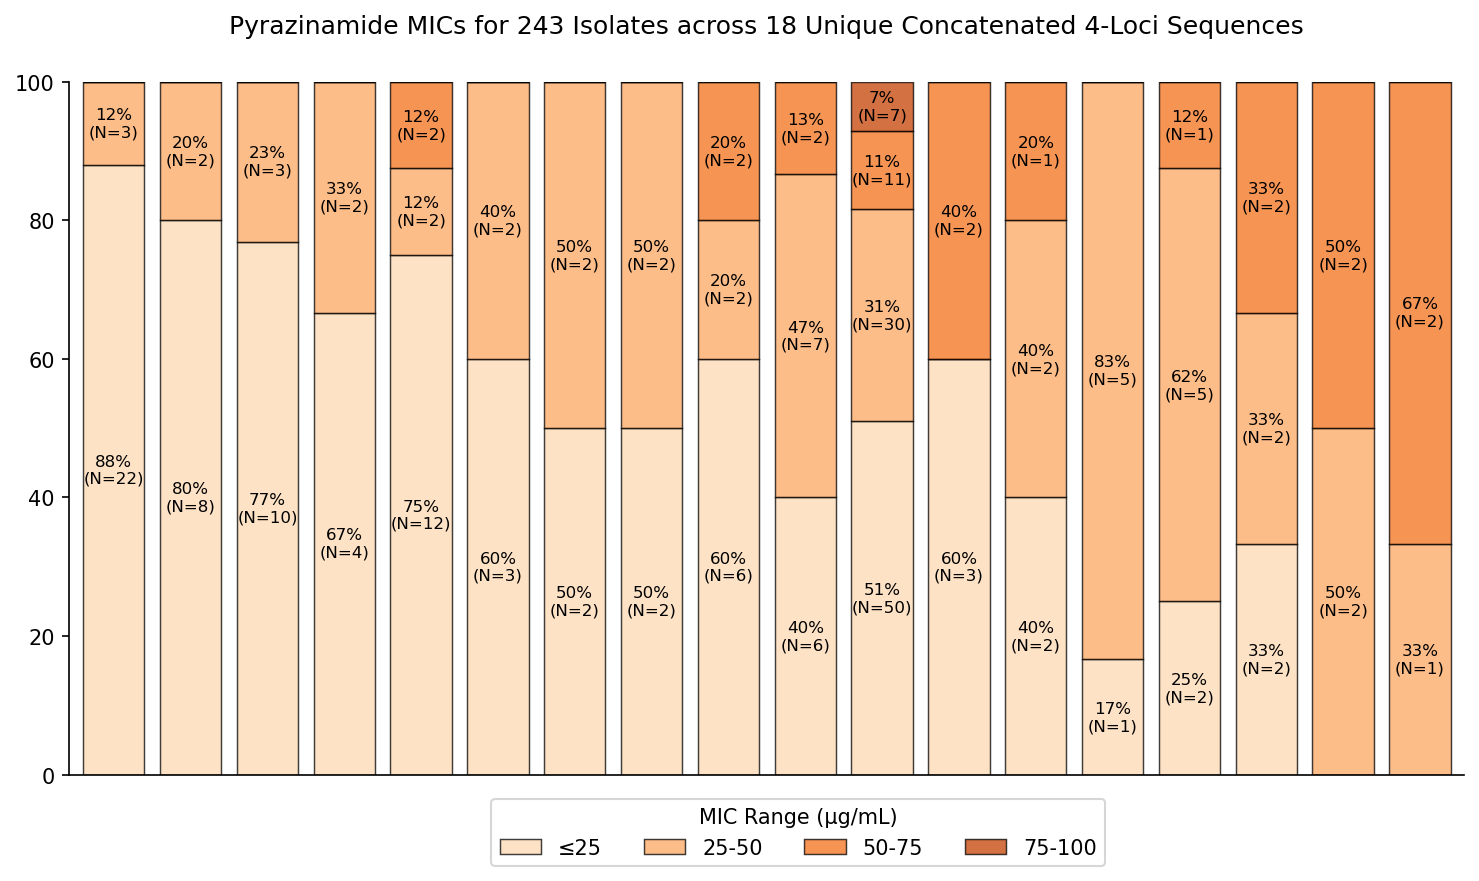

In [117]:
_ = plot_barplot_mics_per_seq("PZA", "Pyrazinamide", PZA_label_encoding_dict, saveFig=True)

# Variants in Isolates

In [126]:
isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/isolate_variants.csv.gz", compression='gzip')

In [127]:
RIF_isolate_variants = isolate_variants.query("Isolate in @RIF_patient_data.SampleID & ((POS > 759309 & POS <= 767683) | (POS > 3877432 & POS <= 3878507))").reset_index(drop=True)
PZA_isolate_variants = isolate_variants.query("Isolate in @PZA_patient_data.SampleID & ((POS > 2286526 & POS <= 2291268) | (POS > 4038050 & POS <= 4040980) | (POS > 1833379 & POS <= 1836386) | (POS > 4042940 & POS <= 4046302))").reset_index(drop=True)

len(RIF_isolate_variants), len(PZA_isolate_variants)

(477, 1124)

In [128]:
def get_syn_variant_counts_by_sample(isolate_variants_df, patient_data_df, drug):

    for i, row in isolate_variants_df.iterrows():
    
        if pd.isnull(row['PROT']):
            isolate_variants_df.loc[i, 'MUT'] = row['GENE'] + '_' + row['NUC']
        else:
            if row['PROT'].replace('p.', '')[:3] == row['PROT'][-3:]:
                isolate_variants_df.loc[i, 'MUT'] = row['GENE'] + '_' + row['NUC']
                isolate_variants_df.loc[i, 'PROT'] = np.nan
            else:
                isolate_variants_df.loc[i, 'MUT'] = row['GENE'] + '_' + row['PROT']

    syn_variants = isolate_variants_df.loc[(pd.isnull(isolate_variants_df['PROT'])) & (~isolate_variants_df['GENE'].str.contains('-'))].reset_index(drop=True)

    # merge with the full list of sample IDs so that isolates without any variants are included here and have a variant count of 0
    syn_variants = syn_variants.merge(patient_data_df[['SampleID']], left_on='Isolate', right_on='SampleID', how='right')
    
    # get the number of synonymous variants per sample. Includes all samples because we merged right above
    syn_variants_by_sample = pd.DataFrame(syn_variants.groupby('SampleID')['MUT'].count()).reset_index()
    
    # add in actual and predicted MICs
    syn_variants_by_sample = syn_variants_by_sample.merge(patient_data_df[['SampleID', f's_{drug.lower()}mic_sputum_specimen_1', 'pred_MIC_group']])

    return isolate_variants_df, syn_variants_by_sample

In [133]:
RIF_isolate_variants, RIF_syn_variants_by_sample = get_syn_variant_counts_by_sample(RIF_isolate_variants, RIF_patient_data, 'RIF')
PZA_isolate_variants, PZA_syn_variants_by_sample = get_syn_variant_counts_by_sample(PZA_isolate_variants, PZA_patient_data, 'PZA')

In [138]:
pd.DataFrame(PZA_isolate_variants.loc[(~pd.isnull(PZA_isolate_variants['PROT'])) & (PZA_isolate_variants['GENE'].isin(['pncA', 'clpC1', 'rpsA', 'panD']))].MUT.value_counts())

,count
MUT,
rpsA_p.Met432Thr,12
pncA_p.Thr114Met,11
rpsA_p.Leu53Val,4
clpC1_p.Asp326Asn,1


In [142]:
pd.DataFrame(PZA_isolate_variants.loc[(pd.isnull(PZA_isolate_variants['PROT'])) & (PZA_isolate_variants['GENE'].isin(['pncA', 'clpC1', 'rpsA', 'panD']))].MUT.value_counts())

,count
MUT,
rpsA_c.636A>C,159
clpC1_c.2418C>T,47
pncA_c.195C>T,10
clpC1_c.1737G>A,7


In [143]:
pd.DataFrame(RIF_isolate_variants.loc[(pd.isnull(RIF_isolate_variants['PROT'])) & (~RIF_isolate_variants['GENE'].str.contains('-'))].MUT.value_counts())

,count
MUT,
rpoB_c.3225T>C,139
rpoC_c.1626C>G,39
rpoC_c.2701C>T,15
rpoB_c.2628T>G,9
rpoB_c.309C>T,6
rpoB_c.390C>T,3
rpoC_c.186C>T,3
rpoA_c.1026C>T,2
rpoC_c.1929G>A,1


In [124]:
for num_syn_var in np.sort(RIF_syn_variants_by_sample.MUT.unique()):

    actual_mic_group = RIF_syn_variants_by_sample.query("MUT==@num_syn_var")['s_rifmic_sputum_specimen_1'].mean()
    #pred_mic_group = RIF_syn_variants_by_samples.query("MUT==@num_syn_var")['pred_MIC_group'].mean() # these are identical because only one group was predicted for all isolates
    print(num_syn_var, actual_mic_group)

0 3.24
1 2.9226519337016574
2 2.6842105263157894
3 2.0


<Axes: xlabel='MUT', ylabel='s_rifmic_sputum_specimen_1'>

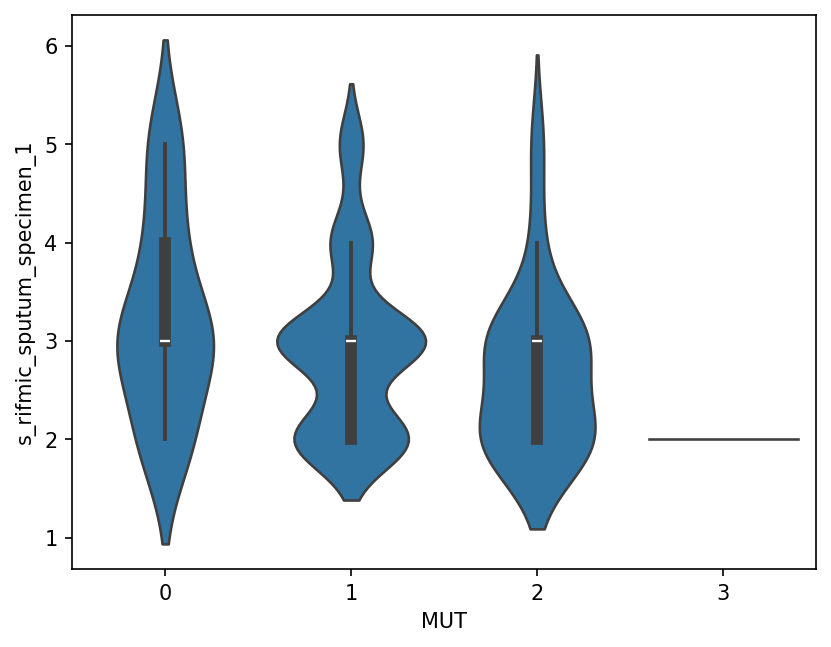

In [125]:
sns.violinplot(data=RIF_syn_variants_by_sample,
              x='MUT',
              y='s_rifmic_sputum_specimen_1'
             )